In [18]:
# install dependencies 
install.packages(c(
  'tidyverse',
  'tidymodels',
  'janitor',
  'skimr',
  'glmnet',
  'ranger',
  'pROC',
  'rlang',
  'scales',
  'corrplot',
  'patchwork',
  'knitr',
  'kableExtra'
))

# load the libraries
library(tidyverse)
library(tidymodels)
library(janitor)
library(skimr)
library(glmnet)
library(ranger)
library(pROC)
library(rlang)
library(scales)      # axis formatting (commas, percentages)
library(corrplot)    # correlation heatmaps
library(patchwork)   # composing multiple ggplots
library(knitr)       # kable() tables
library(kableExtra)  # styled HTML tables

# shared plotting theme and primary colour used throughout the analysis
theme_set(theme_minimal(base_size = 12) +
            theme(panel.grid = element_blank()))
report_fill <- "#2c7fb8"

trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/tidyverse_2.0.0.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/tidymodels_1.5.0.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/janitor_2.2.1.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/skimr_2.2.2.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/glmnet_5.0.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/ranger_0.18.0.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/pROC_1.19.0.1.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/rlang_1.2.0.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/scales_1.4.0.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5/corrplot_0.95.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/big-sur-arm64/contrib/4.5


The downloaded binary packages are in
	/var/folders/rg/flyq5j697ysbkxyry2m15zr80000gn/T//RtmpbhGpbQ/downloaded_packages
corrplot 0.95 loaded

Attaching package: ‘kableExtra’

The following object is masked from ‘package:dplyr’:

    group_rows



In [19]:
# load dataset file paths
path_2023 <- 'flight_with_weather_2023.csv'
path_2024 <- 'flight_with_weather_2024.csv'

In [20]:
# read the data
flight_2023 <- read_csv(path_2023)
flight_2024 <- read_csv(path_2024)

Rows: 6645461 Columns: 34
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (3): OP_CARRIER, ORIGIN, DEST
dbl  (24): OP_CARRIER_FL_NUM, DEP_DELAY, TAXI_OUT, TAXI_IN, ARR_DELAY, CRS_E...
dttm  (7): FL_DATE, CRS_DEP_TIME, DEP_TIME, WHEELS_OFF, WHEELS_ON, CRS_ARR_T...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 6284841 Columns: 34
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (3): OP_CARRIER, ORIGIN, DEST
dbl  (24): OP_CARRIER_FL_NUM, DEP_DELAY, TAXI_OUT, TAXI_IN, ARR_DELAY, CRS_E...
dttm  (7): FL_DATE, CRS_DEP_TIME, DEP_TIME, WHEELS_OFF, WHEELS_ON, CRS_ARR_T...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [21]:
# inspect column names 2023
names(flight_2023)

 [1] "FL_DATE"             "OP_CARRIER"          "OP_CARRIER_FL_NUM"  
 [4] "ORIGIN"              "DEST"                "CRS_DEP_TIME"       
 [7] "DEP_TIME"            "DEP_DELAY"           "TAXI_OUT"           
[10] "WHEELS_OFF"          "WHEELS_ON"           "TAXI_IN"            
[13] "CRS_ARR_TIME"        "ARR_TIME"            "ARR_DELAY"          
[16] "CRS_ELAPSED_TIME"    "ACTUAL_ELAPSED_TIME" "AIR_TIME"           
[19] "FLIGHTS"             "MONTH"               "DAY_OF_MONTH"       
[22] "DAY_OF_WEEK"         "ORIGIN_INDEX"        "DEST_INDEX"         
[25] "O_TEMP"              "O_PRCP"              "O_WSPD"             
[28] "D_TEMP"              "D_PRCP"              "D_WSPD"             
[31] "O_LATITUDE"          "O_LONGITUDE"         "D_LATITUDE"         
[34] "D_LONGITUDE"        

In [22]:
# inspect column names 2024
names(flight_2024)

 [1] "FL_DATE"             "OP_CARRIER"          "OP_CARRIER_FL_NUM"  
 [4] "ORIGIN"              "DEST"                "CRS_DEP_TIME"       
 [7] "DEP_TIME"            "DEP_DELAY"           "TAXI_OUT"           
[10] "WHEELS_OFF"          "WHEELS_ON"           "TAXI_IN"            
[13] "CRS_ARR_TIME"        "ARR_TIME"            "ARR_DELAY"          
[16] "CRS_ELAPSED_TIME"    "ACTUAL_ELAPSED_TIME" "AIR_TIME"           
[19] "FLIGHTS"             "MONTH"               "DAY_OF_MONTH"       
[22] "DAY_OF_WEEK"         "ORIGIN_INDEX"        "DEST_INDEX"         
[25] "O_TEMP"              "O_PRCP"              "O_WSPD"             
[28] "D_TEMP"              "D_PRCP"              "D_WSPD"             
[31] "O_LATITUDE"          "O_LONGITUDE"         "D_LATITUDE"         
[34] "D_LONGITUDE"        

In [23]:
# verify both datasets have identical column names and order
identical(names(flight_2023), names(flight_2024))

[1] TRUE

In [24]:
# check unique values for MONTH column 2023
unique(flight_2023$MONTH)

 [1]  1  2  3  4  5  6  7  8  9 10 11 12

In [25]:
# check unique values for MONTH column 2024
unique(flight_2024$MONTH)

 [1]  1  2  4  5  6  7  8  9 10 11 12

In [26]:
# filter to only keep Dec rows 
dec_flight_2023 <- flight_2023 %>%
  filter(MONTH == 12) %>%
  mutate(YEAR = 2023L)

dec_flight_2024 <- flight_2024 %>%
  filter(MONTH == 12) %>%
  mutate(YEAR = 2024L)

In [27]:
# confirm only December rows remain 2023
unique(dec_flight_2023$MONTH)

[1] 12

In [28]:
# confirm only December rows remain 2024
unique(dec_flight_2024$MONTH)

[1] 12

In [29]:
cat("December 2023:", nrow(dec_flight_2023), "flights\n")
cat("December 2024:", nrow(dec_flight_2024), "flights\n")

December 2023: 558609 flights
December 2024: 574434 flights


In [30]:
# combined both dataset and rename columns to snake_case
df <- bind_rows(dec_flight_2023, dec_flight_2024) %>%
  janitor::clean_names()

In [31]:
glimpse(df)

Rows: 1,133,043
Columns: 35
$ fl_date             <dttm> 2023-12-01, 2023-12-01, 2023-12-01, 2023-12-02, 2…
$ op_carrier          <chr> "DL", "OO", "OO", "DL", "OO", "OO", "DL", "OO", "O…
$ op_carrier_fl_num   <dbl> 1189, 3888, 3920, 1189, 3888, 3920, 1189, 3888, 39…
$ origin              <chr> "DLH", "DLH", "DLH", "DLH", "DLH", "DLH", "DLH", "…
$ dest                <chr> "MSP", "MSP", "MSP", "MSP", "MSP", "MSP", "MSP", "…
$ crs_dep_time        <dttm> 2023-12-01 05:05:00, 2023-12-01 10:44:00, 2023-12…
$ dep_time            <dttm> 2023-12-01 05:23:00, 2023-12-01 10:36:00, 2023-12…
$ dep_delay           <dbl> 18, -8, -5, -7, 0, -5, 1, -6, -8, -8, -7, -5, 0, -…
$ taxi_out            <dbl> 20, 12, 21, 23, 14, 25, 16, 29, 21, 11, 10, 35, 26…
$ wheels_off          <dttm> 2023-12-01 05:43:00, 2023-12-01 10:48:00, 2023-12…
$ wheels_on           <dttm> 2023-12-01 06:14:00, 2023-12-01 11:20:00, 2023-12…
$ taxi_in             <dbl> 3, 4, 5, 6, 7, 4, 4, 5, 5, 3, 3, 3, 5, 5, 8, 3, 4,…
$ crs_arr_ti

In [32]:
skim(df)

── Data Summary ────────────────────────
                           Values 
Name                       df     
Number of rows             1133043
Number of columns          35     
_______________________           
Column type frequency:            
  character                3      
  numeric                  25     
  POSIXct                  7      
________________________          
Group variables            None   

── Variable type: character ────────────────────────────────────────────────────
  skim_variable n_missing complete_rate min max empty n_unique whitespace
1 op_carrier            0             1   2   2     0       15          0
2 origin                0             1   3   3     0      298          0
3 dest                  0             1   3   3     0      298          0

── Variable type: numeric ──────────────────────────────────────────────────────
   skim_variable       n_missing complete_rate     mean       sd     p0    p25
 1 op_carrier_fl_num           0   

In [33]:
# summary statistics by year
df %>%
  group_by(year) %>%
  summarise(
    n_flights        = n(),
    mean_arr_delay   = round(mean(arr_delay, na.rm = TRUE), 2),
    median_arr_delay = round(median(arr_delay, na.rm = TRUE), 2),
    delay_rate_pct   = round(mean(arr_delay > 15, na.rm = TRUE) * 100, 2),
    mean_dep_delay   = round(mean(dep_delay, na.rm = TRUE), 2),
    n_carriers       = n_distinct(op_carrier),
    n_airports       = n_distinct(origin),
    .groups = "drop"
  )

# A tibble: 2 × 8
   year n_flights mean_arr_delay median_arr_delay delay_rate_pct mean_dep_delay
  <int>     <int>          <dbl>            <dbl>          <dbl>          <dbl>
1  2023    558609           0.43               -8           15.0           8.16
2  2024    574434           6.95               -6           20.4          13.3 
# ℹ 2 more variables: n_carriers <int>, n_airports <int>

In [34]:
# December flight counts per year, with a bold total row.
tibble(
  Year                = c("December 2023", "December 2024", "Total"),
  `Number of Flights` = c(558609, 574434, 1133043)
) |>
  kable(caption = "December flight records by year.",
        format.args = list(big.mark = ","),
        align = c("l", "r")) |>
  kable_styling(full_width = FALSE, bootstrap_options = c("striped", "hover")) |>
  row_spec(3, bold = TRUE)

Year,Number of Flights
December 2023,"558,609"
December 2024,"574,434"
Total,"1,133,043"


In [35]:
tibble(
  Category = c("Flight Identification", "Temporal", "Delay / Operational",
               "Weather (Origin)", "Weather (Destination)", "Geospatial"),
  Variables = c(
    "op_carrier, op_carrier_fl_num, origin, dest",
    "fl_date, crs_dep_time, dep_time, crs_arr_time, arr_time, month, day_of_month, day_of_week",
    "dep_delay, arr_delay, taxi_out, taxi_in, air_time, crs_elapsed_time, actual_elapsed_time, wheels_off, wheels_on, flights",
    "o_temp, o_prcp, o_wspd",
    "d_temp, d_prcp, d_wspd",
    "o_latitude, o_longitude, d_latitude, d_longitude"
  )
) |>
  kable(caption = "The 35 variables grouped into six conceptual categories.",
        align = c("l", "l")) |>
  kable_styling(full_width = FALSE, bootstrap_options = c("striped", "hover")) |>
  column_spec(1, bold = TRUE)

Category,Variables
Flight Identification,"op_carrier, op_carrier_fl_num, origin, dest"
Temporal,"fl_date, crs_dep_time, dep_time, crs_arr_time, arr_time, month, day_of_month, day_of_week"
Delay / Operational,"dep_delay, arr_delay, taxi_out, taxi_in, air_time, crs_elapsed_time, actual_elapsed_time, wheels_off, wheels_on, flights"
Weather (Origin),"o_temp, o_prcp, o_wspd"
Weather (Destination),"d_temp, d_prcp, d_wspd"
Geospatial,"o_latitude, o_longitude, d_latitude, d_longitude"


In [36]:
# Tabulate how many columns fall into each broad data type.
tibble(variable = names(df),
       type     = map_chr(df, ~ class(.x)[1])) |>
  mutate(type_group = case_when(
    type %in% c("POSIXct", "Date", "IDate", "ITime") ~ "Datetime",
    type %in% c("numeric", "integer", "double")      ~ "Numeric",
    TRUE                                              ~ "Character")) |>
  count(type_group, name = "n_columns") |>
  kable(caption = "Number of columns by broad data type.") |>
  kable_styling(full_width = FALSE, bootstrap_options = c("striped", "hover"))

type_group,n_columns
Character,3
Datetime,7
Numeric,25


In [37]:
# Identify columns that carry no information
df |>
  summarise(across(everything(), n_distinct)) |>
  pivot_longer(everything(), names_to = "variable", values_to = "n_unique") |>
  filter(n_unique <= 1) |>
  kable(caption = "Constant columns (single unique value = zero predictive value).") |>
  kable_styling(full_width = FALSE, bootstrap_options = c("striped", "hover"))

variable,n_unique
flights,1
month,1


In [38]:
# summary of df
skim(df) |> yank("numeric")


── Variable type: numeric ──────────────────────────────────────────────────────
   skim_variable  n_missing complete_rate   mean     sd   p0  p25  p50  p75 p100
 1 op_carrier_fl…         0             1 2.42e3 1.62e3    1 1103 2142 3562 8819
 2 dep_delay              0             1 1.08e1 5.20e1  -99   -6   -2    8 3786
 3 taxi_out               0             1 1.80e1 9.42e0    1   12   16   21  184
 4 taxi_in                0             1 8.23e0 6.60e0    1    4    6   10  244
 5 arr_delay              0             1 3.74e0 5.40e1 -126  -17   -7    7 3795
 6 crs_elapsed_t…         0             1 1.50e2 7.40e1   20   95  134  182 1003
 7 actual_elapse…         0             1 1.43e2 7.32e1   16   90  127  175  743
 8 air_time               0             1 1.17e2 7.14e1    6   65  100  147  673
 9 flights                0             1 1   e0 0         1    1    1    1    1
10 month                  0             1 1.2 e1 0        12   12   12   12   12
# ℹ 15 more rows
# ℹ 1 more

In [39]:
# check missing values
missing_summary <- df |>
  summarise(across(everything(), ~ sum(is.na(.x)))) |>
  pivot_longer(everything(), names_to = "variable", values_to = "n_missing") |>
  mutate(pct_missing = round(100 * n_missing / nrow(df), 3)) |>
  filter(n_missing > 0) |>
  arrange(desc(n_missing))

missing_summary |>
  kable(caption = "Columns containing missing values.") |>
  kable_styling(full_width = FALSE, bootstrap_options = c("striped", "hover"))

variable,n_missing,pct_missing
d_temp,771,0.068
d_prcp,771,0.068
d_wspd,771,0.068
o_temp,216,0.019
o_prcp,216,0.019
o_wspd,216,0.019


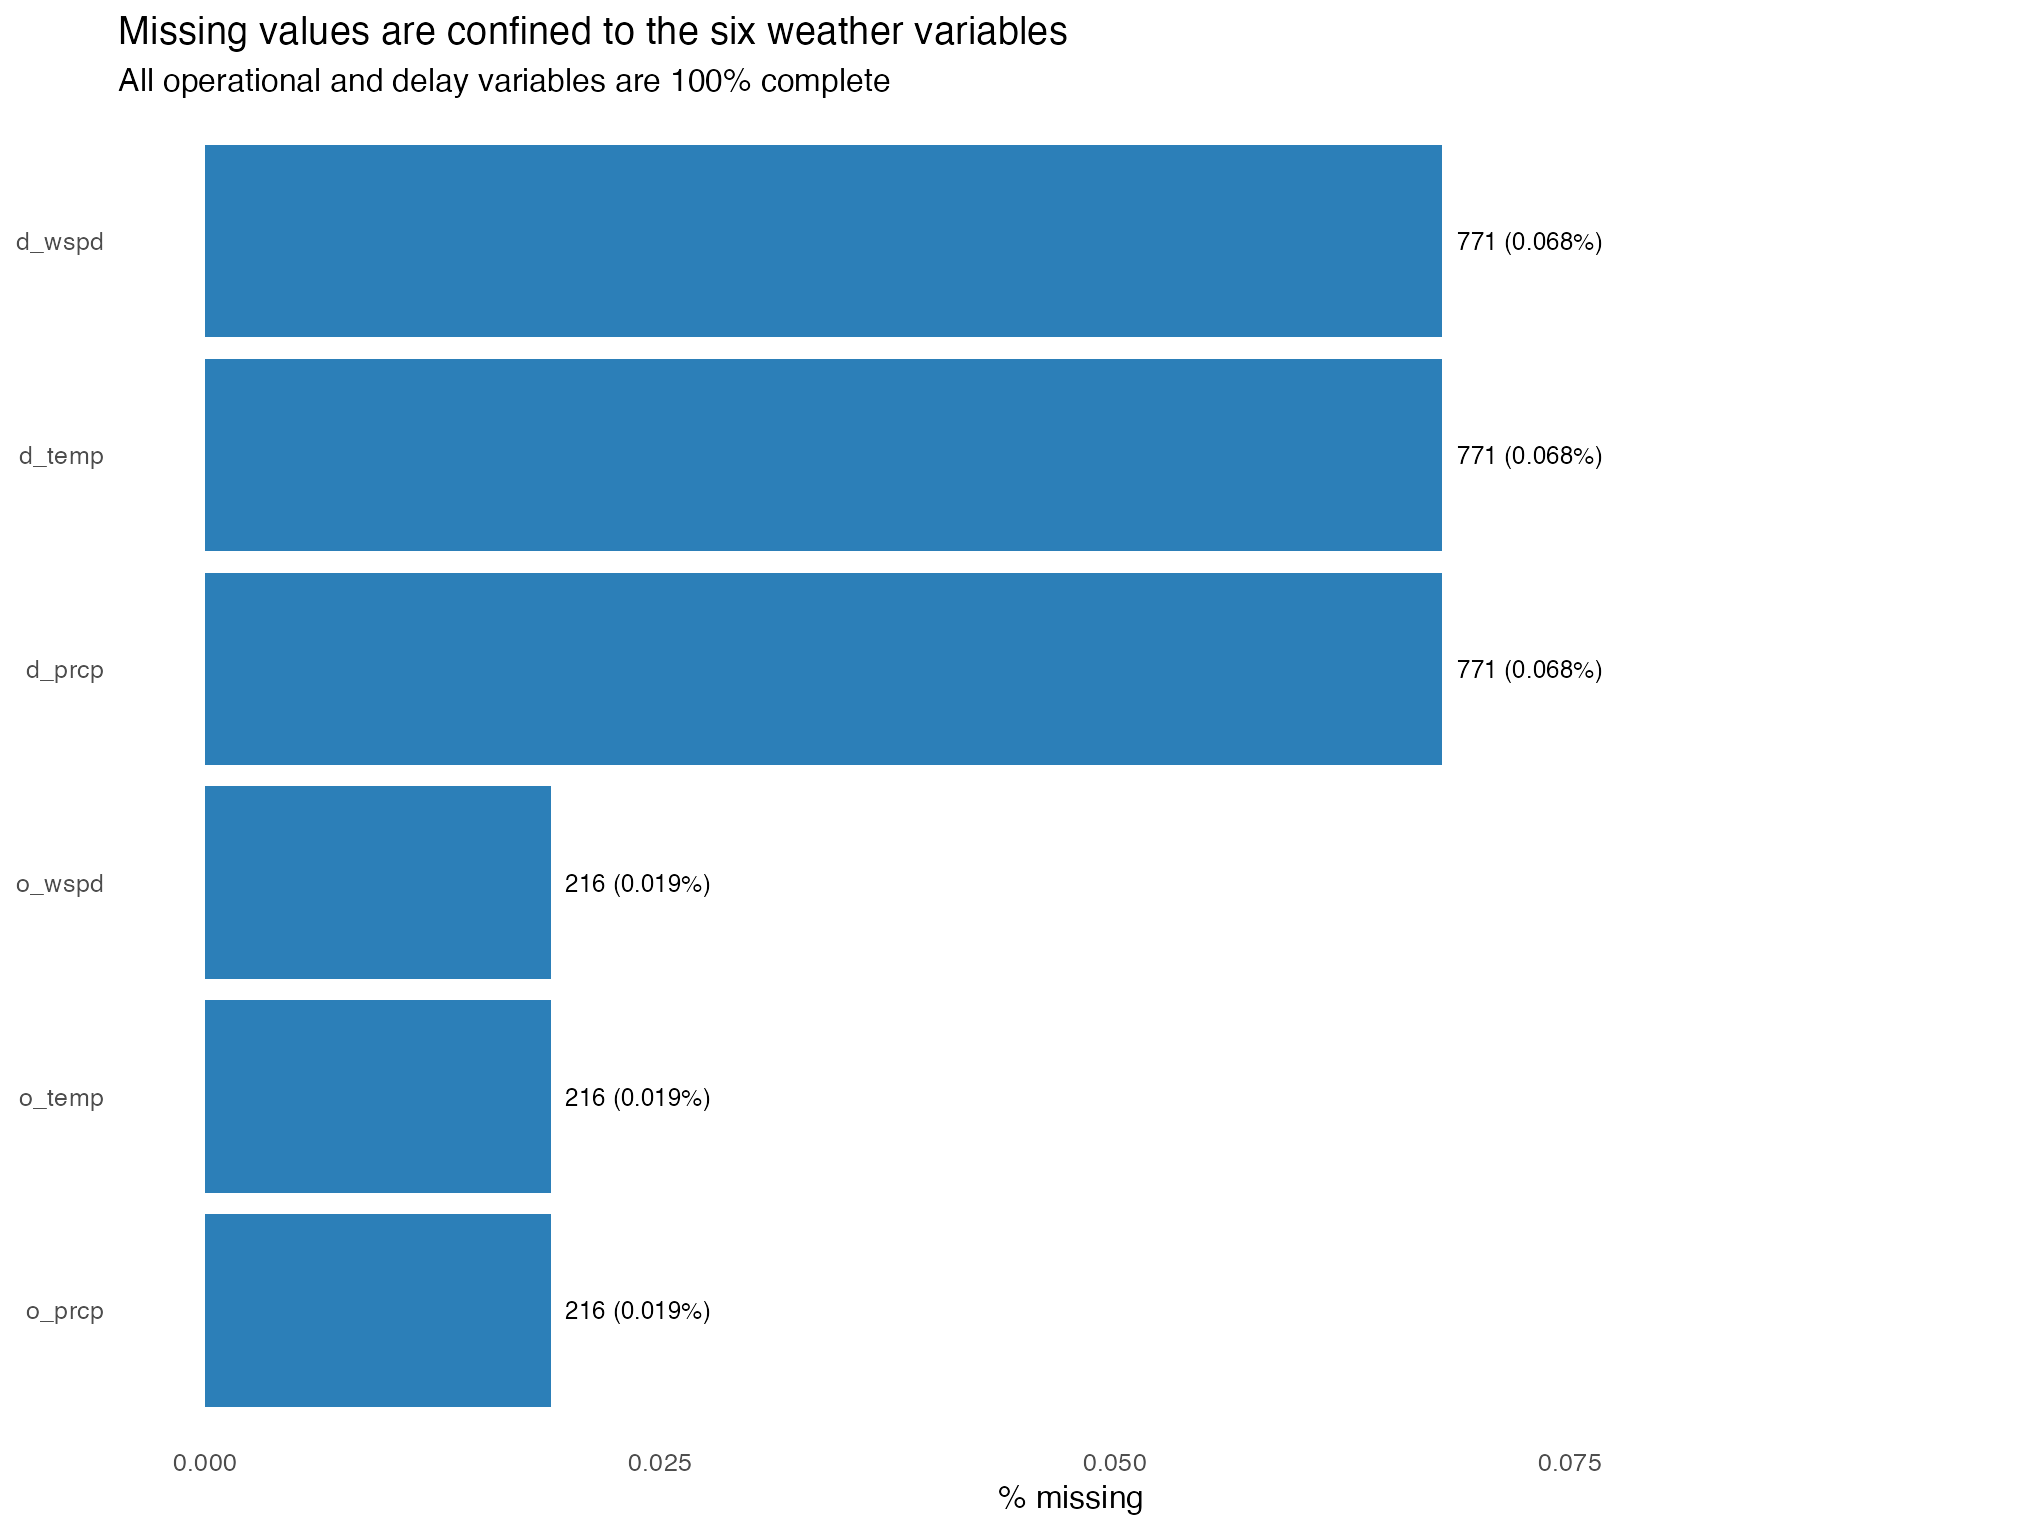

In [40]:
missing_summary |>
  ggplot(aes(x = reorder(variable, pct_missing), y = pct_missing)) +
  geom_col(fill = report_fill) +
  geom_text(aes(label = paste0(n_missing, " (", pct_missing, "%)")),
            hjust = -0.1, size = 3.2) +
  coord_flip(ylim = c(0, max(missing_summary$pct_missing) * 1.4)) +
  labs(title = "Missing values are confined to the six weather variables",
       subtitle = "All operational and delay variables are 100% complete",
       x = NULL, y = "% missing")

In [59]:
# check for duplicate 
n_dupes <- sum(duplicated(df))
cat("duplicated rows:", n_dupes, "\n")

duplicated rows: 0 


In [42]:
# inspecting values fall within physically plausible ranges.
validity <- tibble(
  check = c("Negative air_time",
            "Negative taxi_out",
            "Negative taxi_in",
            "CRS departure timestamps missing",
            "Actual departure timestamps missing",
            "Months other than December",
            "arr_delay outside [-180, 4000] min",
            "dep_delay outside [-180, 4000] min"),
  n = c(sum(df$air_time < 0, na.rm = TRUE),
        sum(df$taxi_out < 0, na.rm = TRUE),
        sum(df$taxi_in  < 0, na.rm = TRUE),
        sum(is.na(df$crs_dep_time)),
        sum(is.na(df$dep_time)),
        sum(df$month != 12),
        sum(df$arr_delay < -180 | df$arr_delay > 4000),
        sum(df$dep_delay < -180 | df$dep_delay > 4000)))

validity |>
  kable(caption = "Data-validity checks (all counts should be 0).") |>
  kable_styling(full_width = FALSE, bootstrap_options = c("striped", "hover"))

check,n
Negative air_time,0
Negative taxi_out,0
Negative taxi_in,0
CRS departure timestamps missing,0
Actual departure timestamps missing,0
Months other than December,0
"arr_delay outside [-180, 4000] min",0
"dep_delay outside [-180, 4000] min",0


In [43]:
# Quantify the extreme right tail of arrival delay using the IQR rule.
q  <- quantile(df$arr_delay, c(.25, .75))
iqr <- diff(q)
upper_fence <- q[2] + 1.5 * iqr

df |>
  summarise(
    p95          = quantile(arr_delay, 0.95),
    p99          = quantile(arr_delay, 0.99),
    max          = max(arr_delay),
    upper_fence  = upper_fence,
    n_above_fence = sum(arr_delay > upper_fence),
    pct_above    = round(100 * mean(arr_delay > upper_fence), 2)) |>
  kable(caption = "Upper-tail outlier diagnostics for arr_delay (minutes).") |>
  kable_styling(full_width = FALSE, bootstrap_options = c("striped", "hover"))

p95,p99,max,upper_fence,n_above_fence,pct_above
68,193,3795,43,92010,8.12


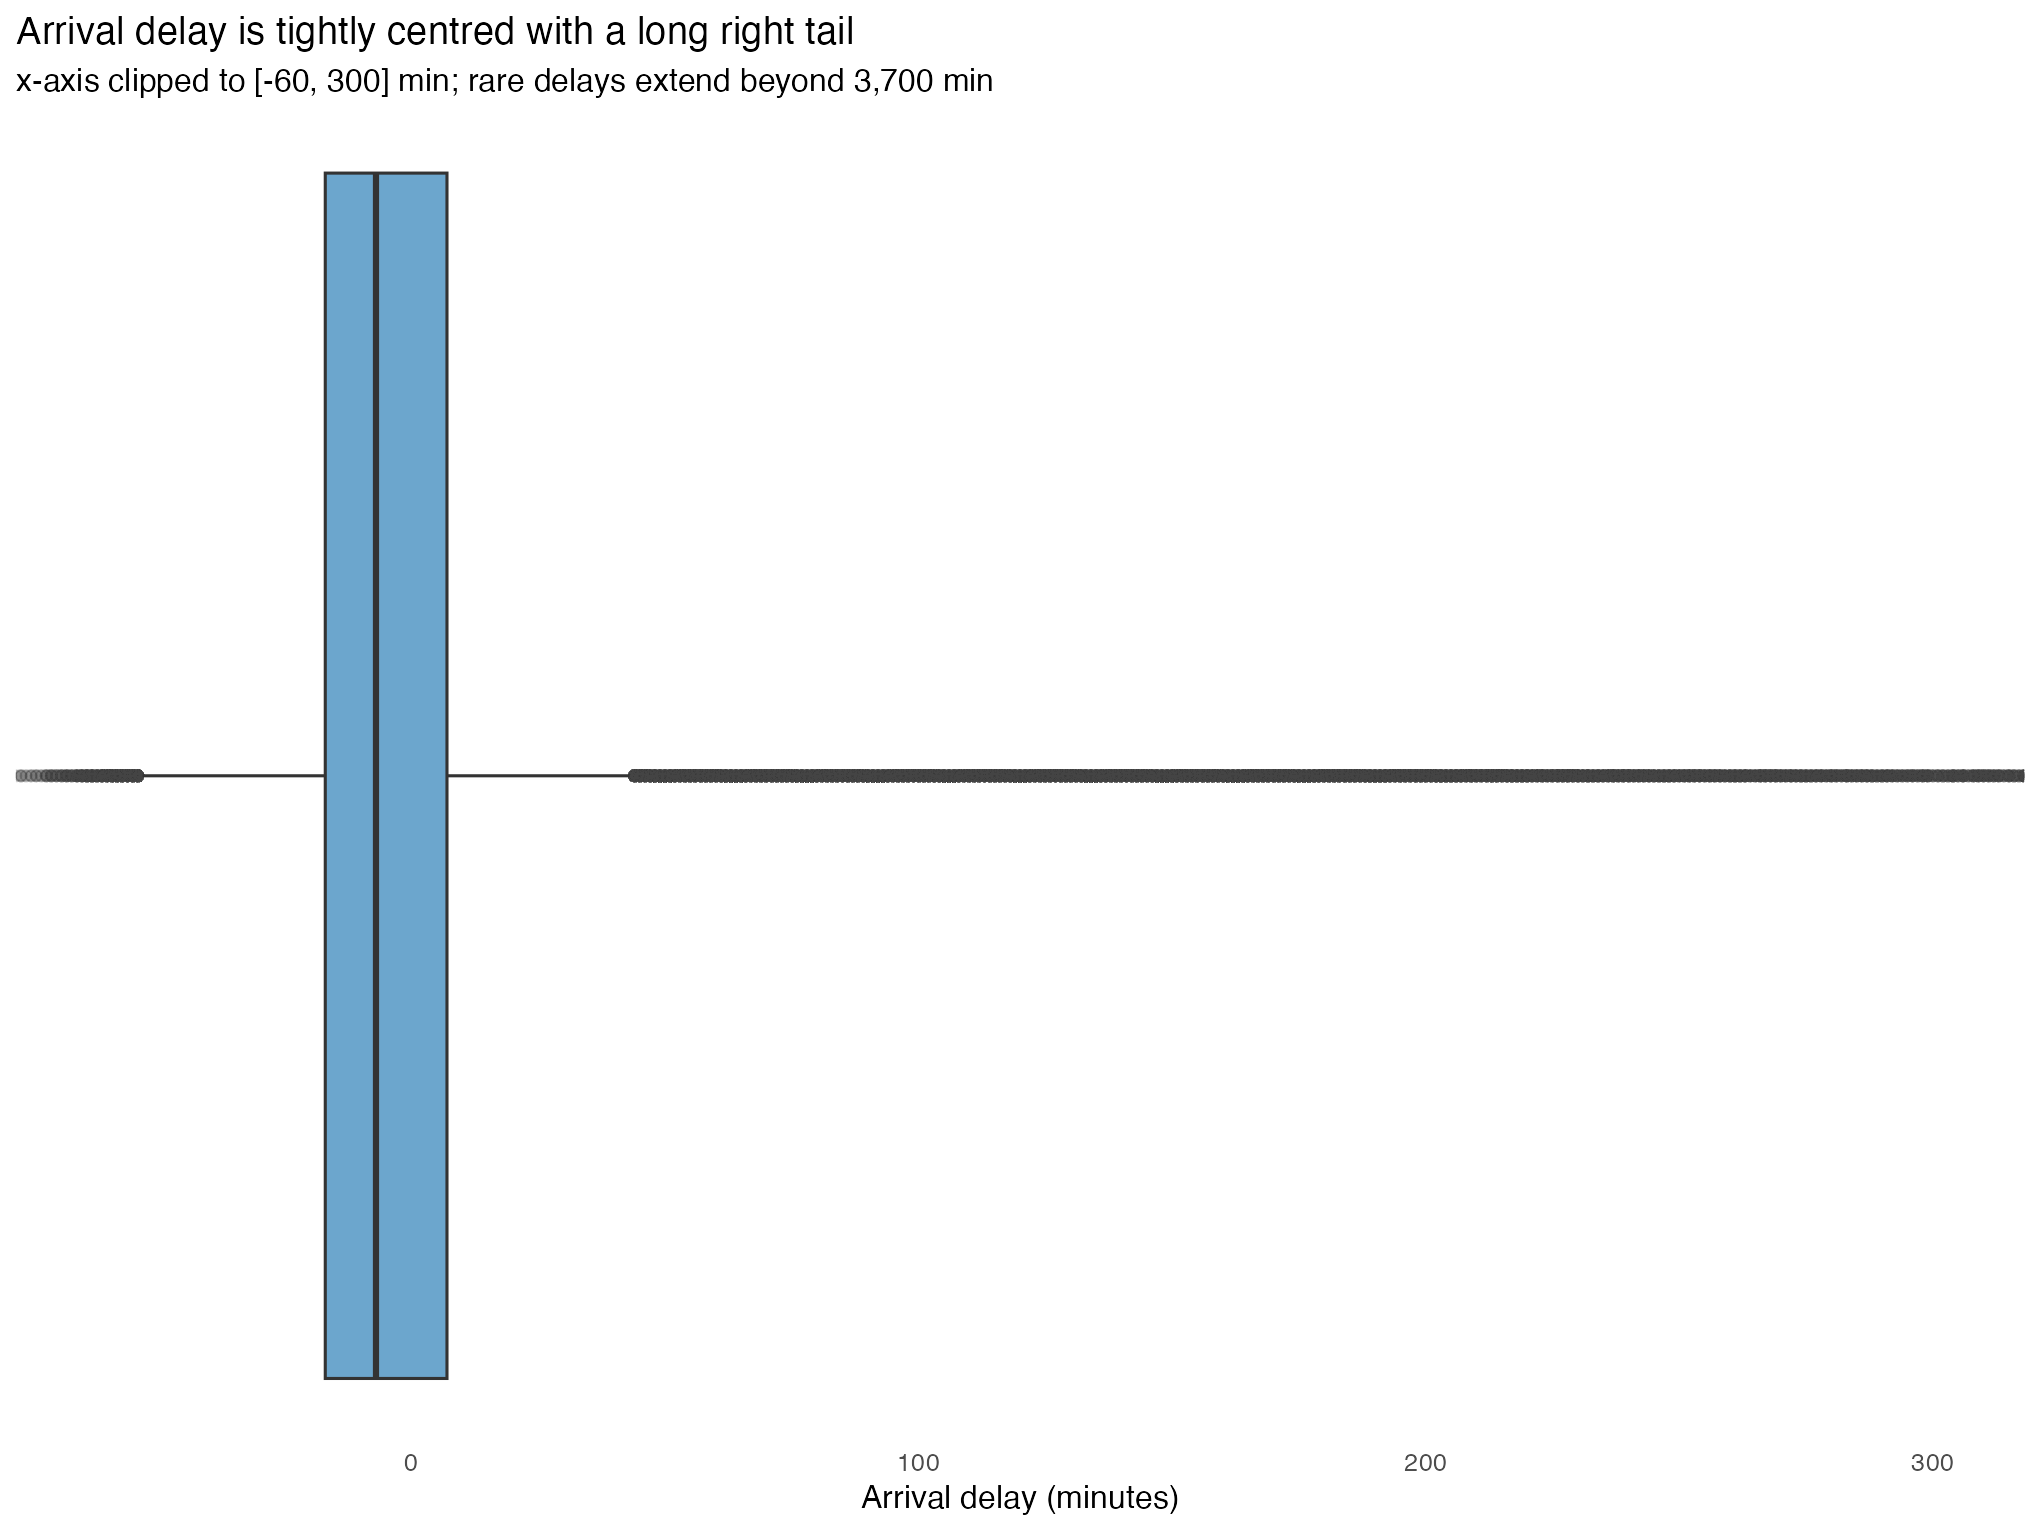

In [44]:
# Boxplot of arrival delay, with the x-axis clipped so the body is legible.
ggplot(df, aes(x = arr_delay)) +
  geom_boxplot(fill = report_fill, alpha = 0.7, outlier.alpha = 0.05) +
  coord_cartesian(xlim = c(-60, 300)) +
  labs(title = "Arrival delay is tightly centred with a long right tail",
       subtitle = "x-axis clipped to [-60, 300] min; rare delays extend beyond 3,700 min",
       x = "Arrival delay (minutes)", y = NULL) +
  theme(axis.text.y = element_blank())

In [45]:
#  - drop the two constant columns (month, flights);
#  - derive the binary classification target;
#  - extract scheduled departure hour and a time-of-day band;
#  - add a weekend flag and human-readable weekday labels;
#  - construct a route identifier;
#  - set year and day_of_week as ordered factors for clean plotting.

weekday_labels <- c("Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun")

df_clean <- df |>
  select(-month, -flights) |>                       # remove zero-information columns
  mutate(
    year        = factor(year),
    dep_hour    = as.integer(format(crs_dep_time, "%H")),
    time_of_day = cut(dep_hour,
                      breaks = c(-1, 5, 11, 16, 20, 24),
                      labels = c("Overnight (0-5)", "Morning (6-11)",
                                 "Afternoon (12-16)", "Evening (17-20)",
                                 "Late (21-23)")),
    weekday     = factor(weekday_labels[day_of_week], levels = weekday_labels),
    is_weekend  = day_of_week %in% c(6, 7),
    route       = paste(origin, dest, sep = "-"),
    # Classification target: significant arrival delay (> 15 minutes).
    is_delayed  = factor(if_else(arr_delay > 15, "Delayed", "OnTime"),
                         levels = c("OnTime", "Delayed"))
  )

cat("Cleaned dataset:", nrow(df_clean), "rows x", ncol(df_clean), "columns\n")
glimpse(df_clean |> select(year, dep_hour, time_of_day, weekday, is_weekend,
                           route, arr_delay, is_delayed))

Cleaned dataset: 1133043 rows x 39 columns
Rows: 1,133,043
Columns: 8
$ year        <fct> 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023…
$ dep_hour    <int> 5, 10, 18, 5, 10, 18, 5, 10, 18, 5, 10, 18, 5, 10, 18, 5, …
$ time_of_day <fct> Overnight (0-5), Morning (6-11), Evening (17-20), Overnigh…
$ weekday     <fct> Fri, Fri, Fri, Sat, Sat, Sat, Sun, Sun, Sun, Mon, Mon, Mon…
$ is_weekend  <lgl> FALSE, FALSE, FALSE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, F…
$ route       <chr> "DLH-MSP", "DLH-MSP", "DLH-MSP", "DLH-MSP", "DLH-MSP", "DL…
$ arr_delay   <dbl> -2, -29, -19, -20, -15, -18, -24, -6, -27, -39, -30, -9, -…
$ is_delayed  <fct> OnTime, OnTime, OnTime, OnTime, OnTime, OnTime, OnTime, On…


is_delayed,n,pct
OnTime,"931,892",82.25
Delayed,"201,151",17.75


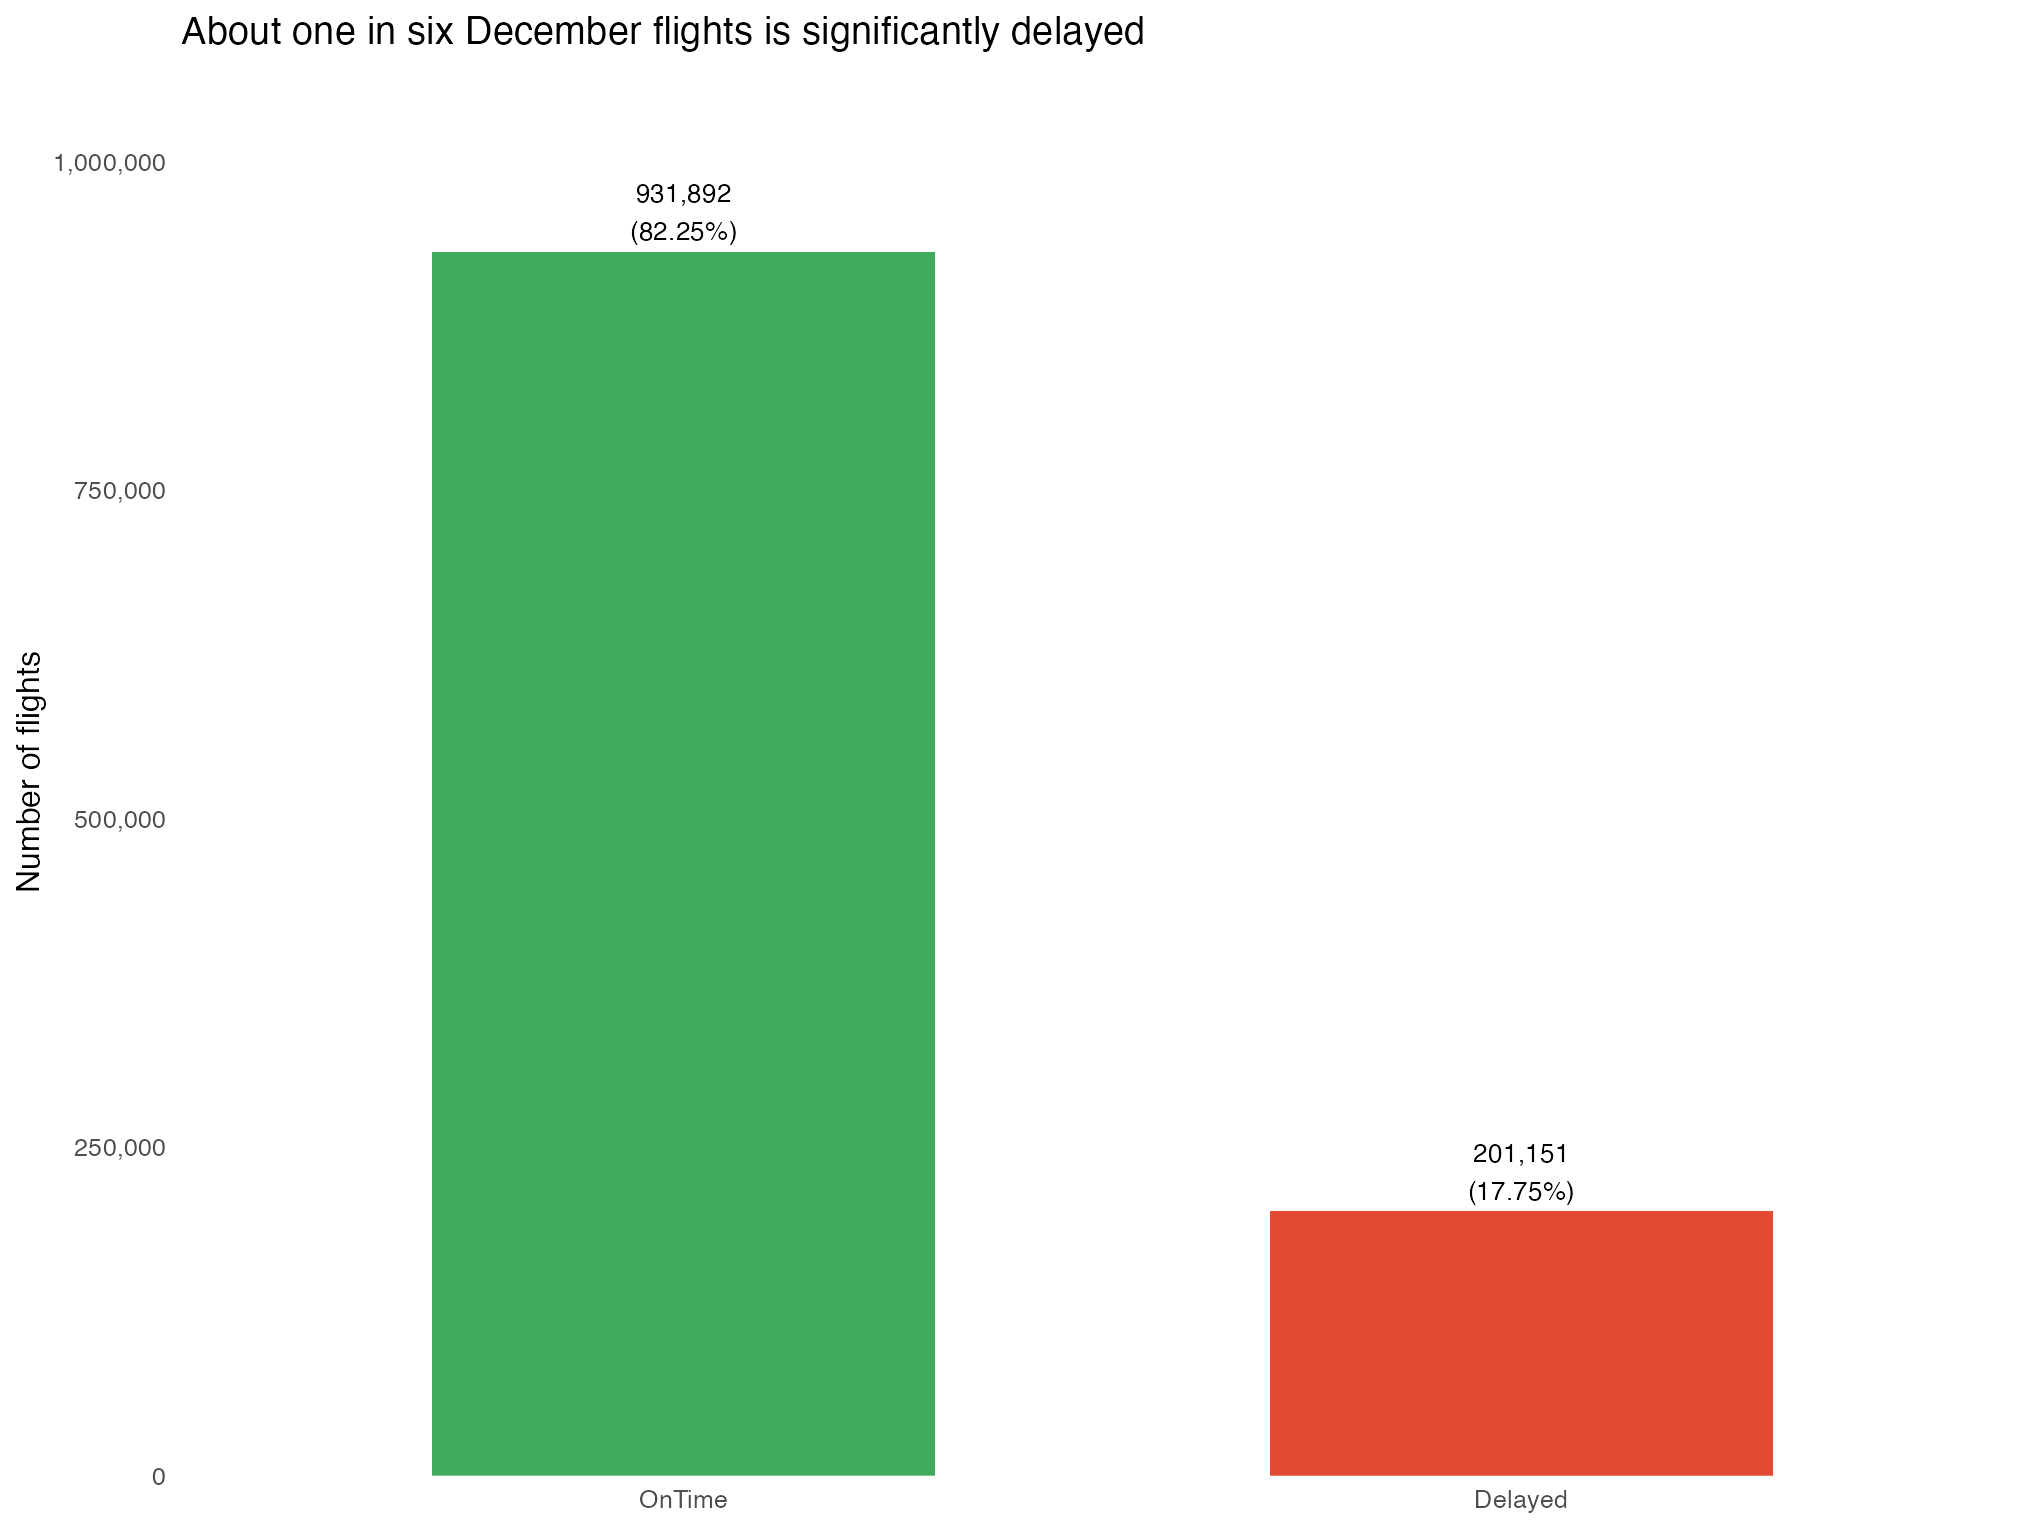

In [46]:
# review target distribution
target_tab <- df_clean |>
  count(is_delayed) |>
  mutate(pct = round(100 * n / sum(n), 2))

target_tab |>
  kable(caption = "Class distribution of the delay target (arr_delay > 15 min).",
        format.args = list(big.mark = ",")) |>
  kable_styling(full_width = FALSE, bootstrap_options = c("striped", "hover"))

ggplot(target_tab, aes(is_delayed, n, fill = is_delayed)) +
  geom_col(width = 0.6) +
  geom_text(aes(label = paste0(comma(n), "\n(", pct, "%)")), vjust = -0.2, size = 3.5) +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.15))) +
  scale_fill_manual(values = c(OnTime = "#41ab5d", Delayed = "#e34a33")) +
  labs(title = "About one in six December flights is significantly delayed",
       x = NULL, y = "Number of flights") +
  theme(legend.position = "none")

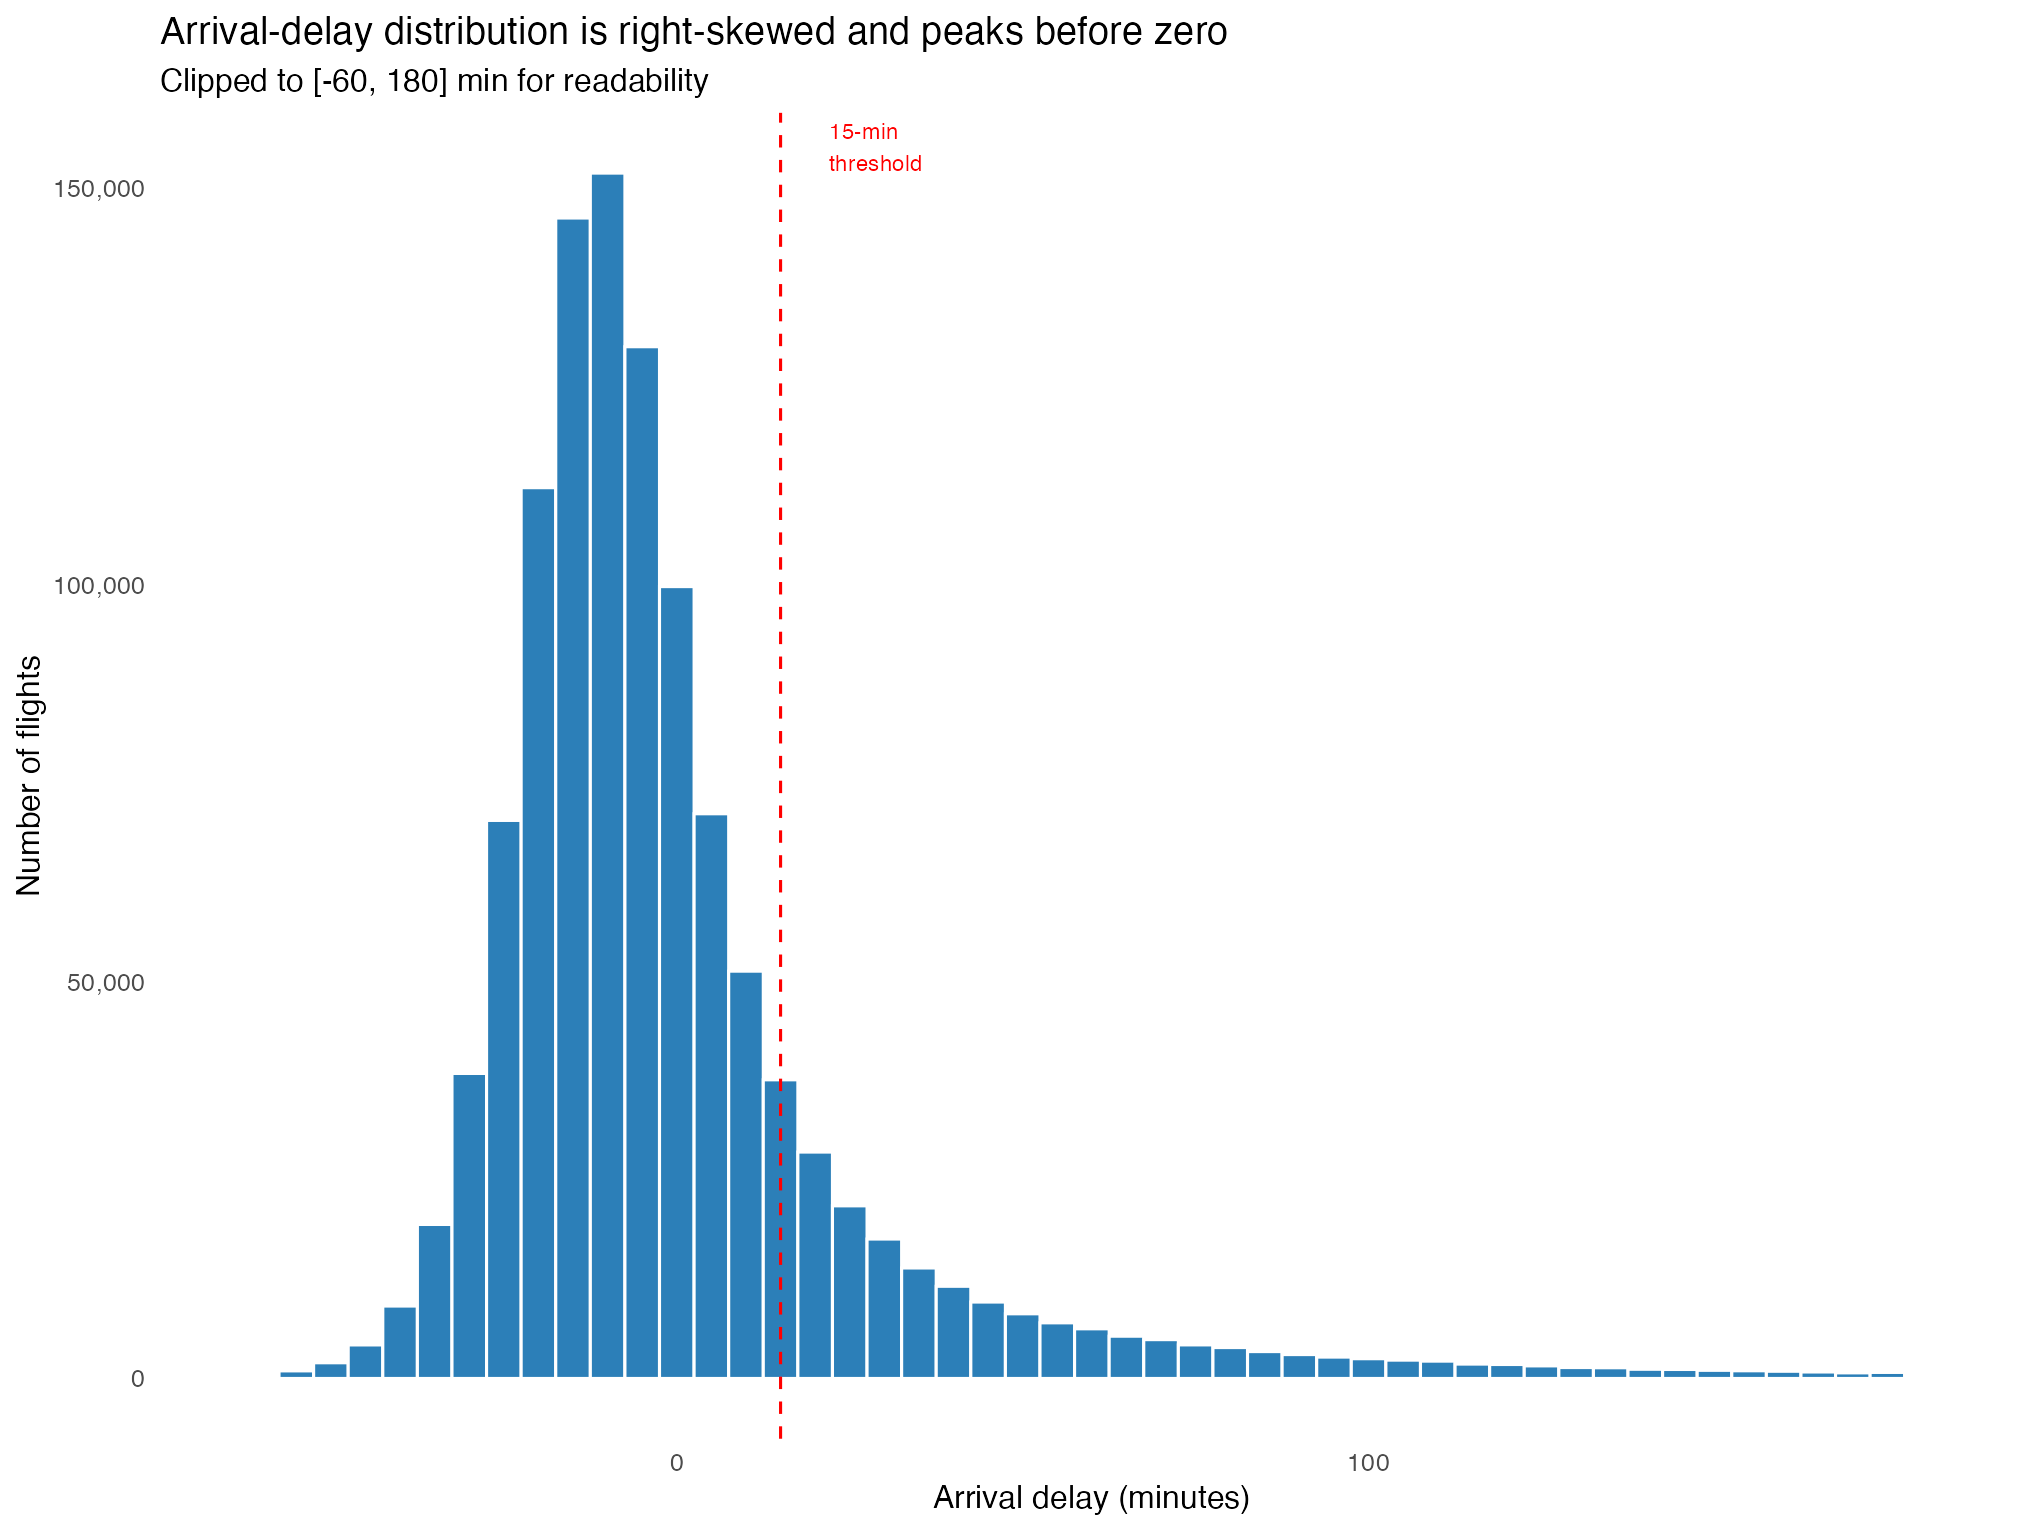

In [47]:
ggplot(filter(df_clean, arr_delay >= -60, arr_delay <= 180),
       aes(arr_delay)) +
  geom_histogram(binwidth = 5, fill = report_fill, colour = "white") +
  geom_vline(xintercept = 15, linetype = "dashed", colour = "red") +
  annotate("text", x = 22, y = Inf, label = "15-min\nthreshold",
           colour = "red", hjust = 0, vjust = 1.2, size = 3) +
  scale_y_continuous(labels = comma) +
  labs(title = "Arrival-delay distribution is right-skewed and peaks before zero",
       subtitle = "Clipped to [-60, 180] min for readability",
       x = "Arrival delay (minutes)", y = "Number of flights")

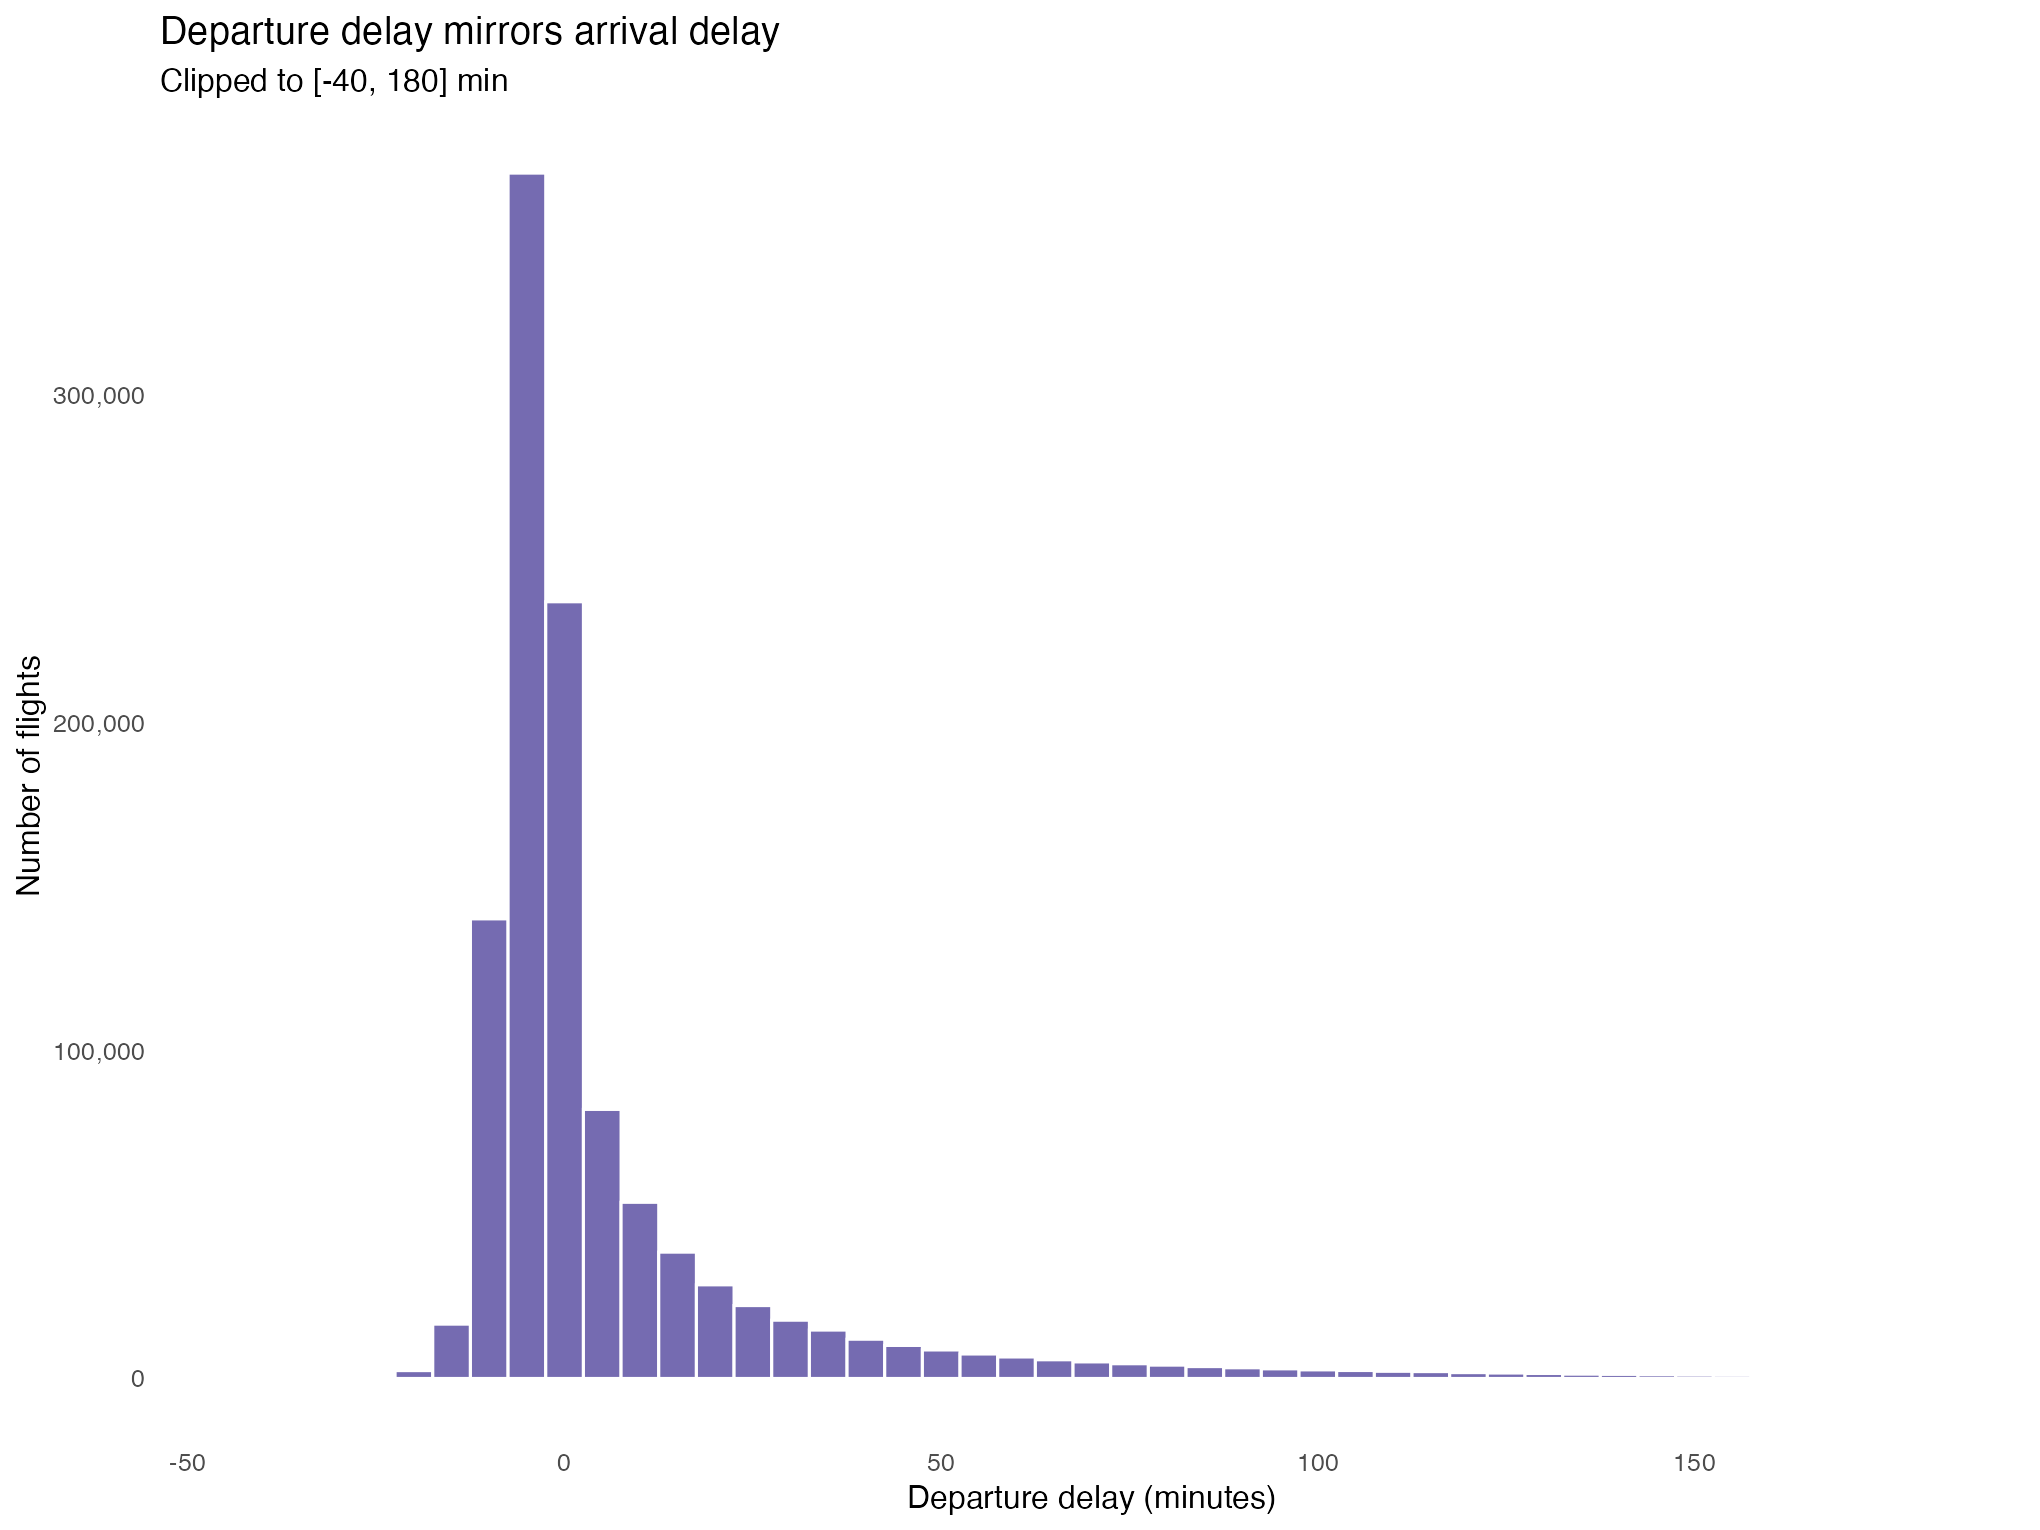

In [48]:
ggplot(filter(df_clean, dep_delay >= -40, dep_delay <= 180),
       aes(dep_delay)) +
  geom_histogram(binwidth = 5, fill = "#756bb1", colour = "white") +
  scale_y_continuous(labels = comma) +
  labs(title = "Departure delay mirrors arrival delay",
       subtitle = "Clipped to [-40, 180] min",
       x = "Departure delay (minutes)", y = "Number of flights")

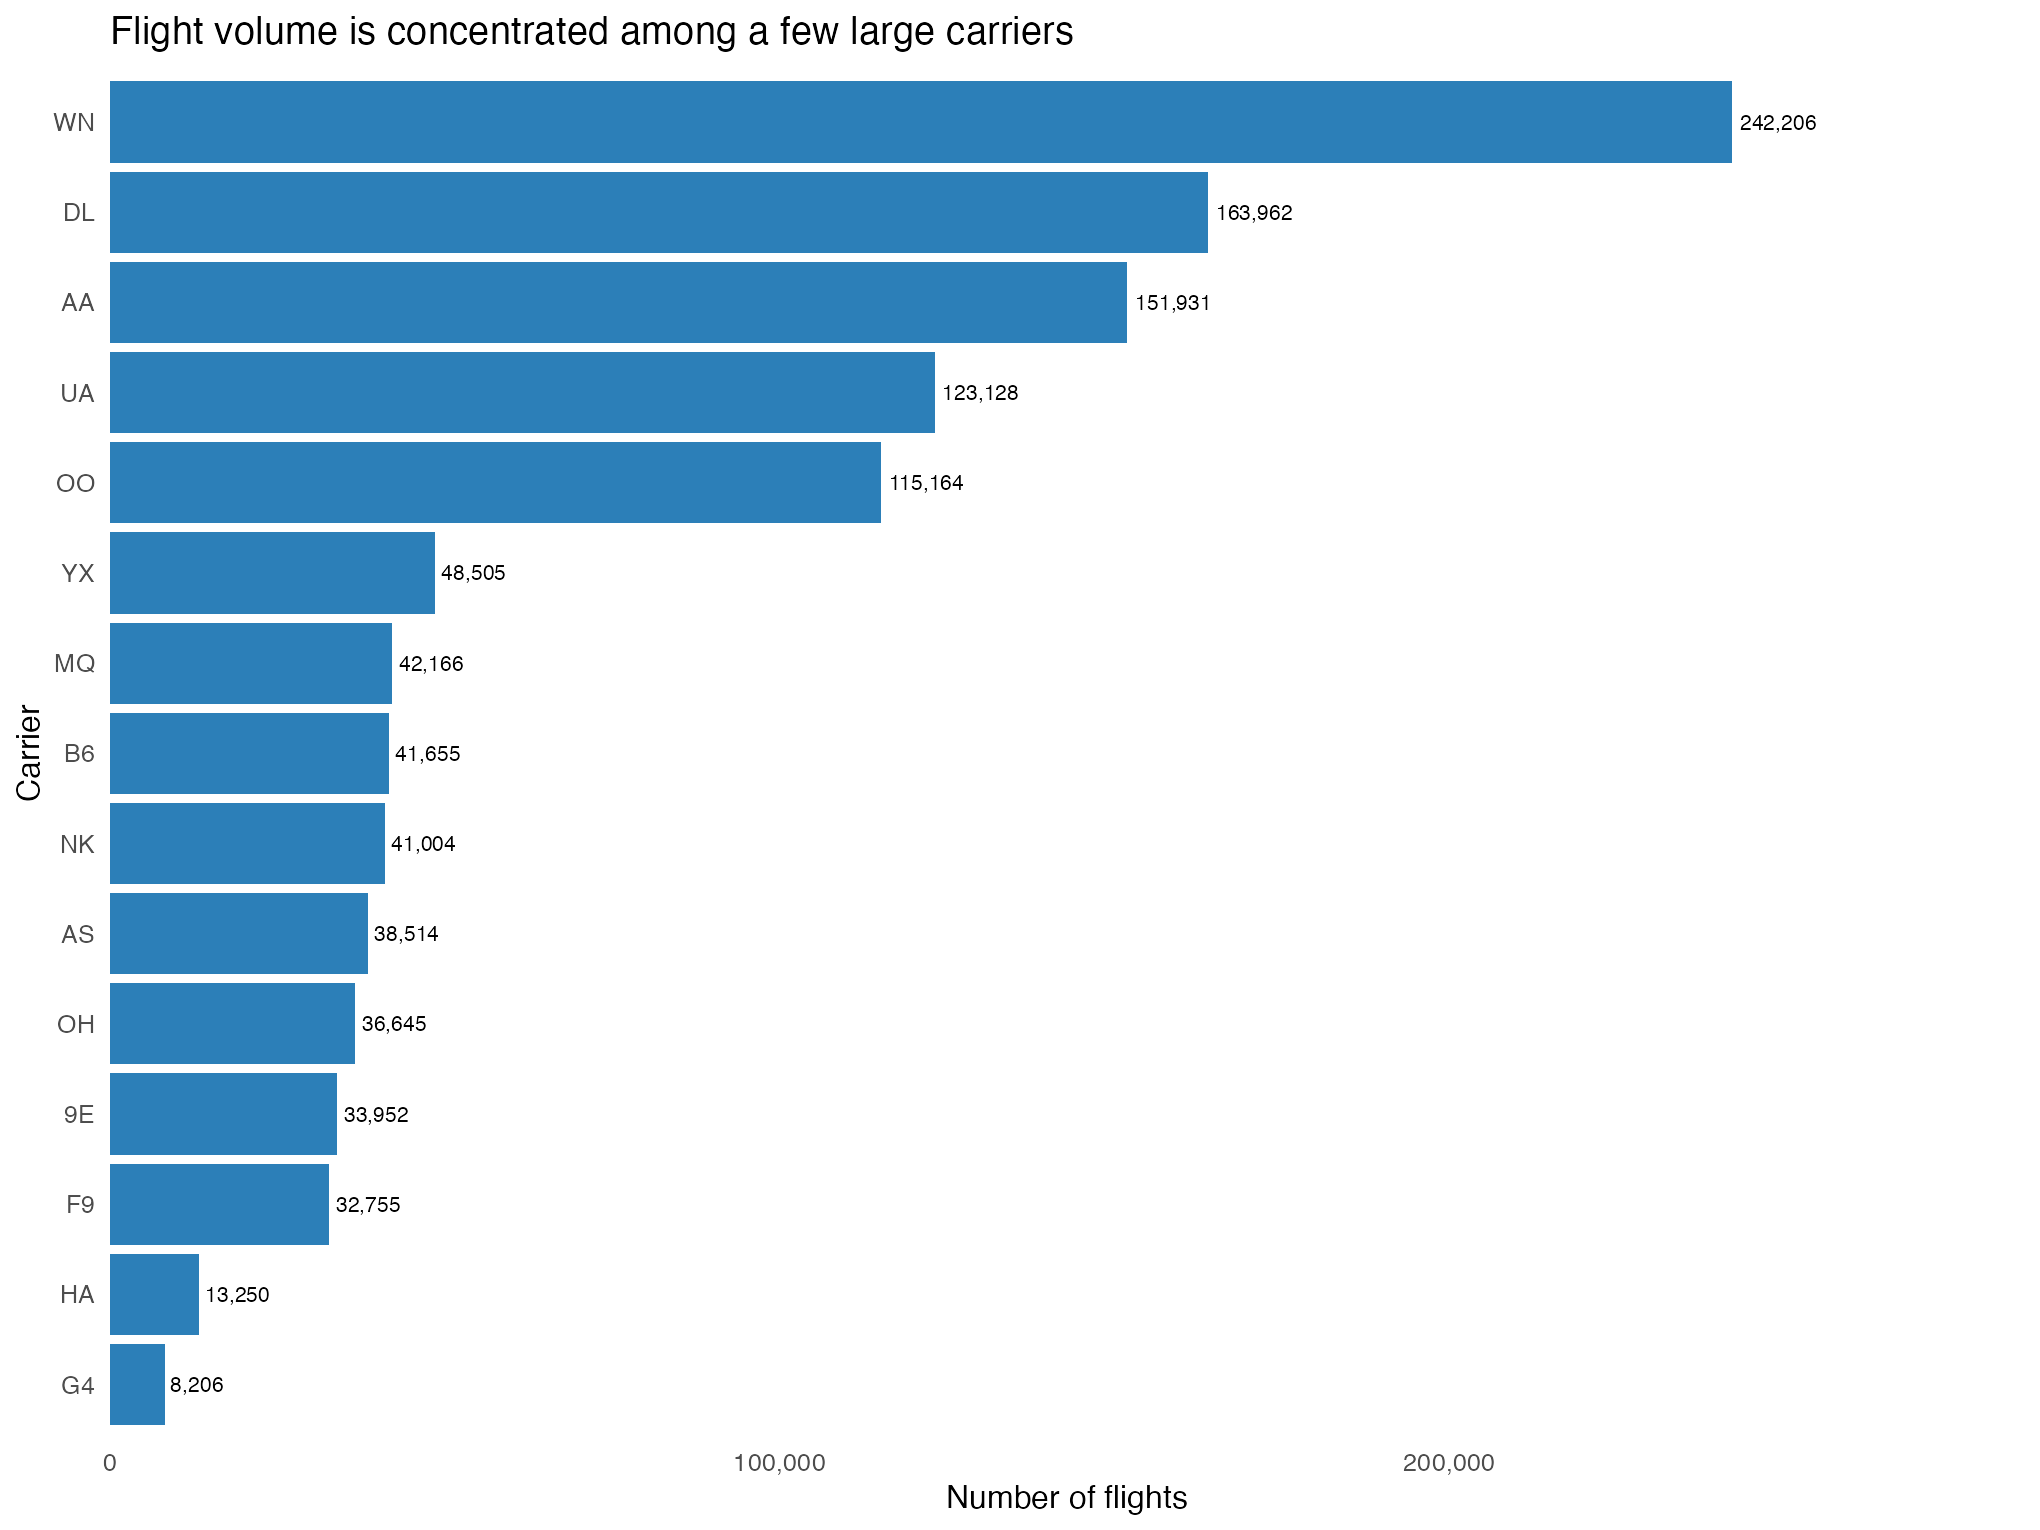

In [49]:
df_clean |>
  count(op_carrier, sort = TRUE) |>
  ggplot(aes(reorder(op_carrier, n), n)) +
  geom_col(fill = report_fill) +
  geom_text(aes(label = comma(n)), hjust = -0.1, size = 2.8) +
  coord_flip(clip = "off") +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.18))) +
  labs(title = "Flight volume is concentrated among a few large carriers",
       x = "Carrier", y = "Number of flights")

Warning message:
Removed 648 rows containing non-finite outside the scale range (`stat_bin()`). 


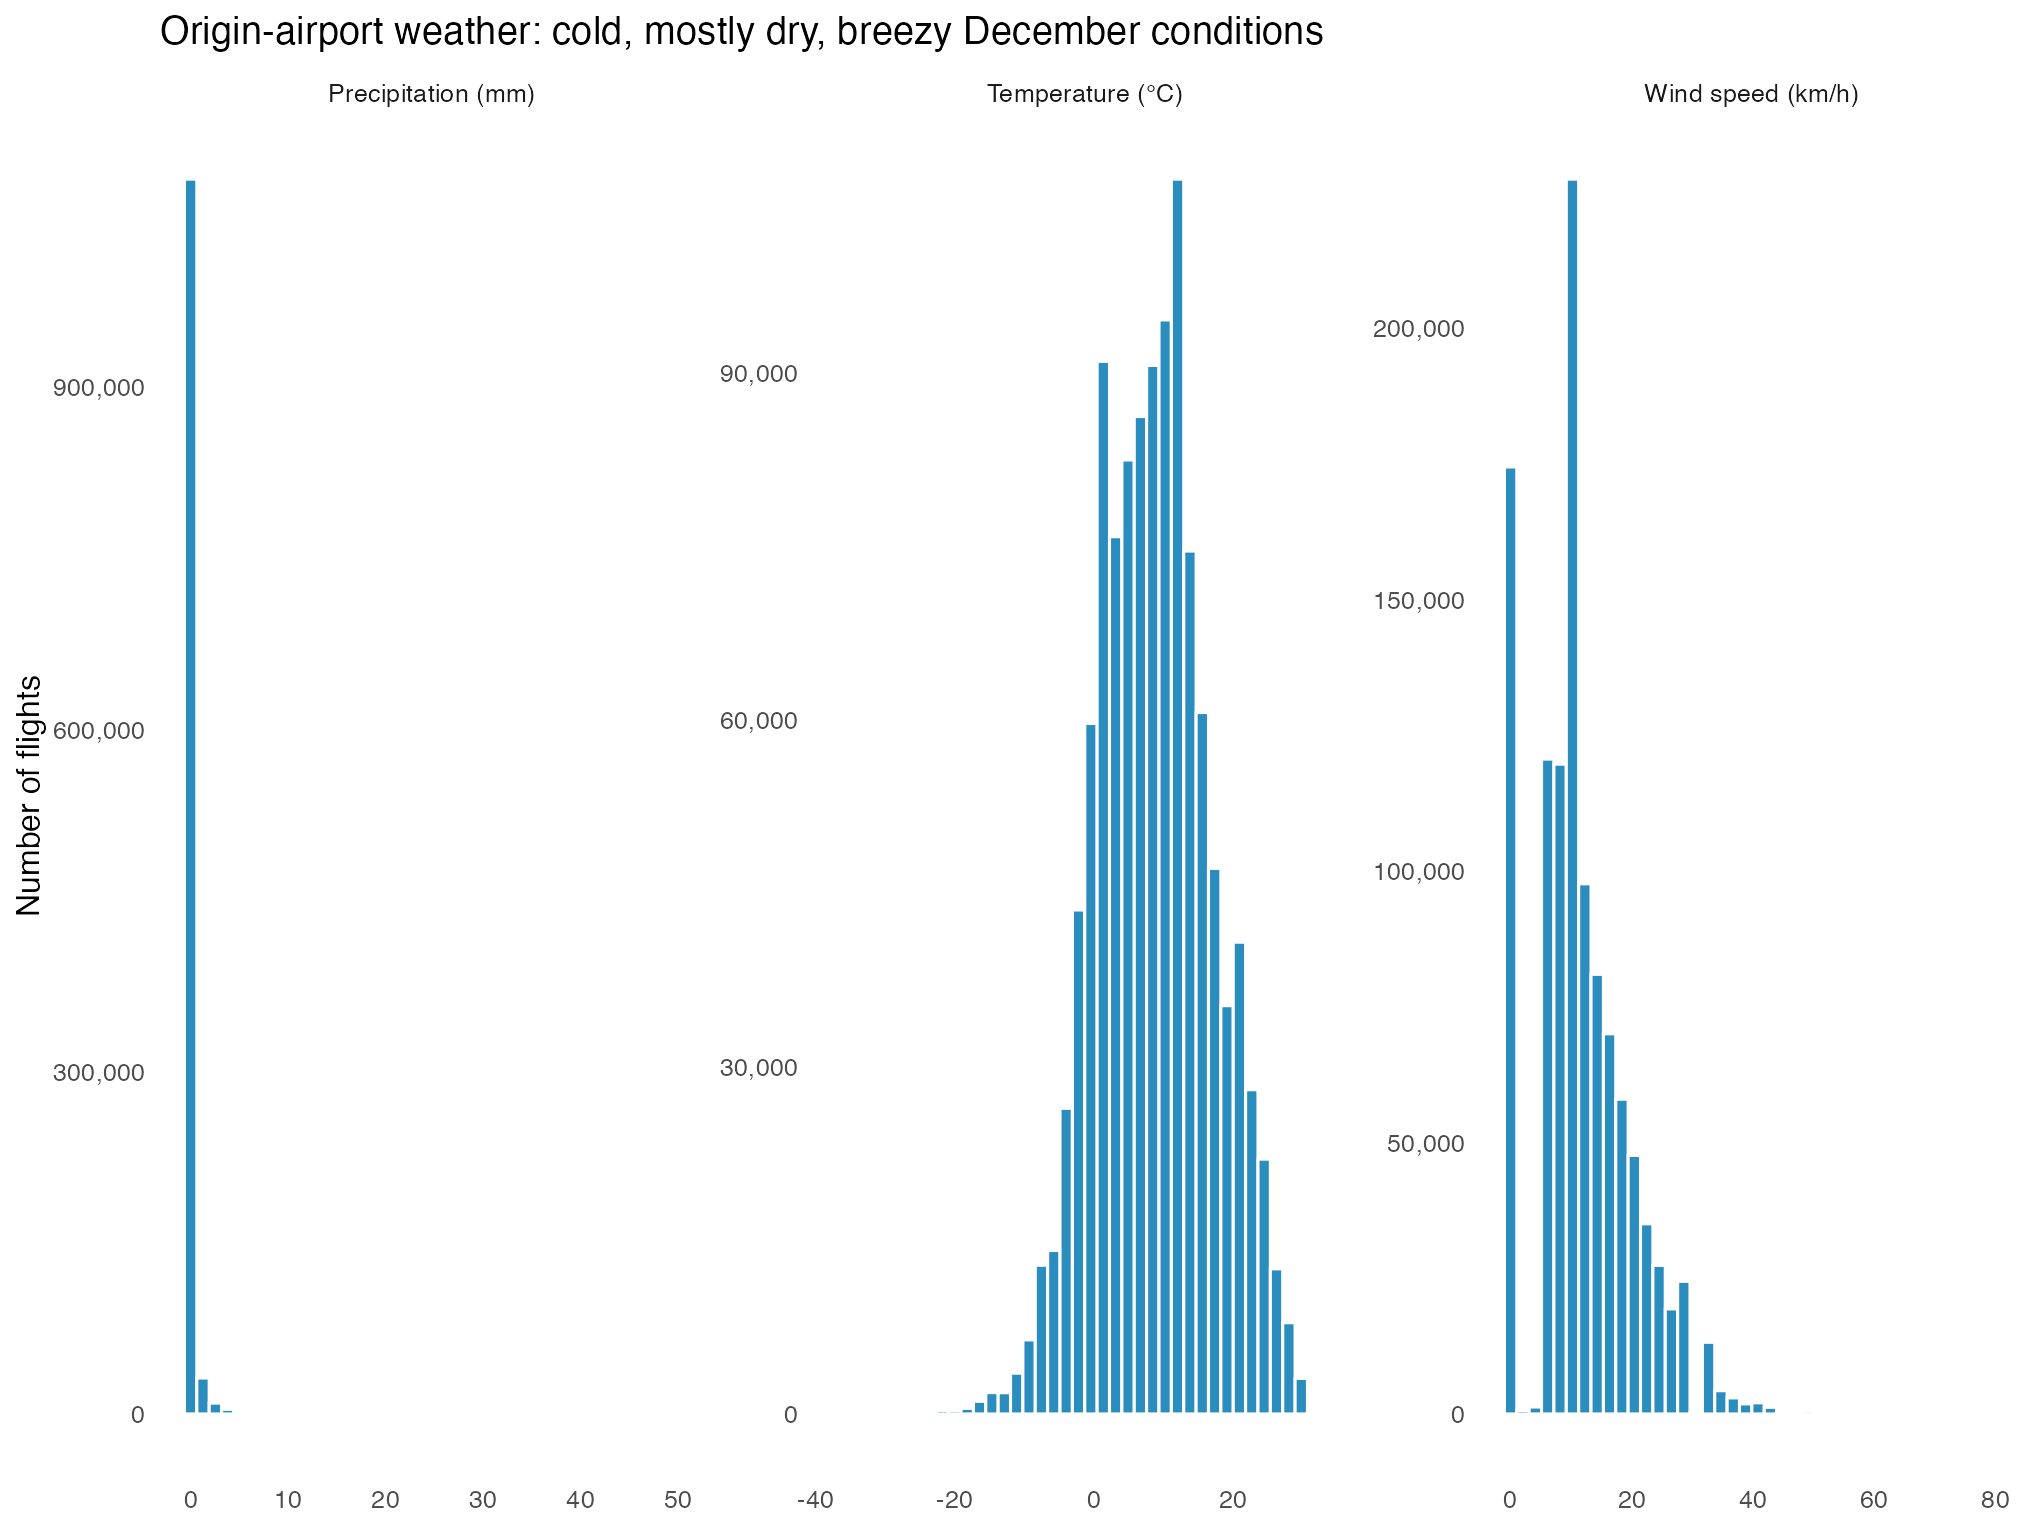

In [50]:
# Origin-airport weather distributions on a common panel.
df_clean |>
  select(o_temp, o_prcp, o_wspd) |>
  pivot_longer(everything(), names_to = "var", values_to = "value") |>
  mutate(var = recode(var,
                      o_temp = "Temperature (\u00b0C)",
                      o_prcp = "Precipitation (mm)",
                      o_wspd = "Wind speed (km/h)")) |>
  ggplot(aes(value)) +
  geom_histogram(bins = 40, fill = "#2b8cbe", colour = "white") +
  facet_wrap(~ var, scales = "free", ncol = 3) +
  scale_y_continuous(labels = comma) +
  labs(title = "Origin-airport weather: cold, mostly dry, breezy December conditions",
       x = NULL, y = "Number of flights")

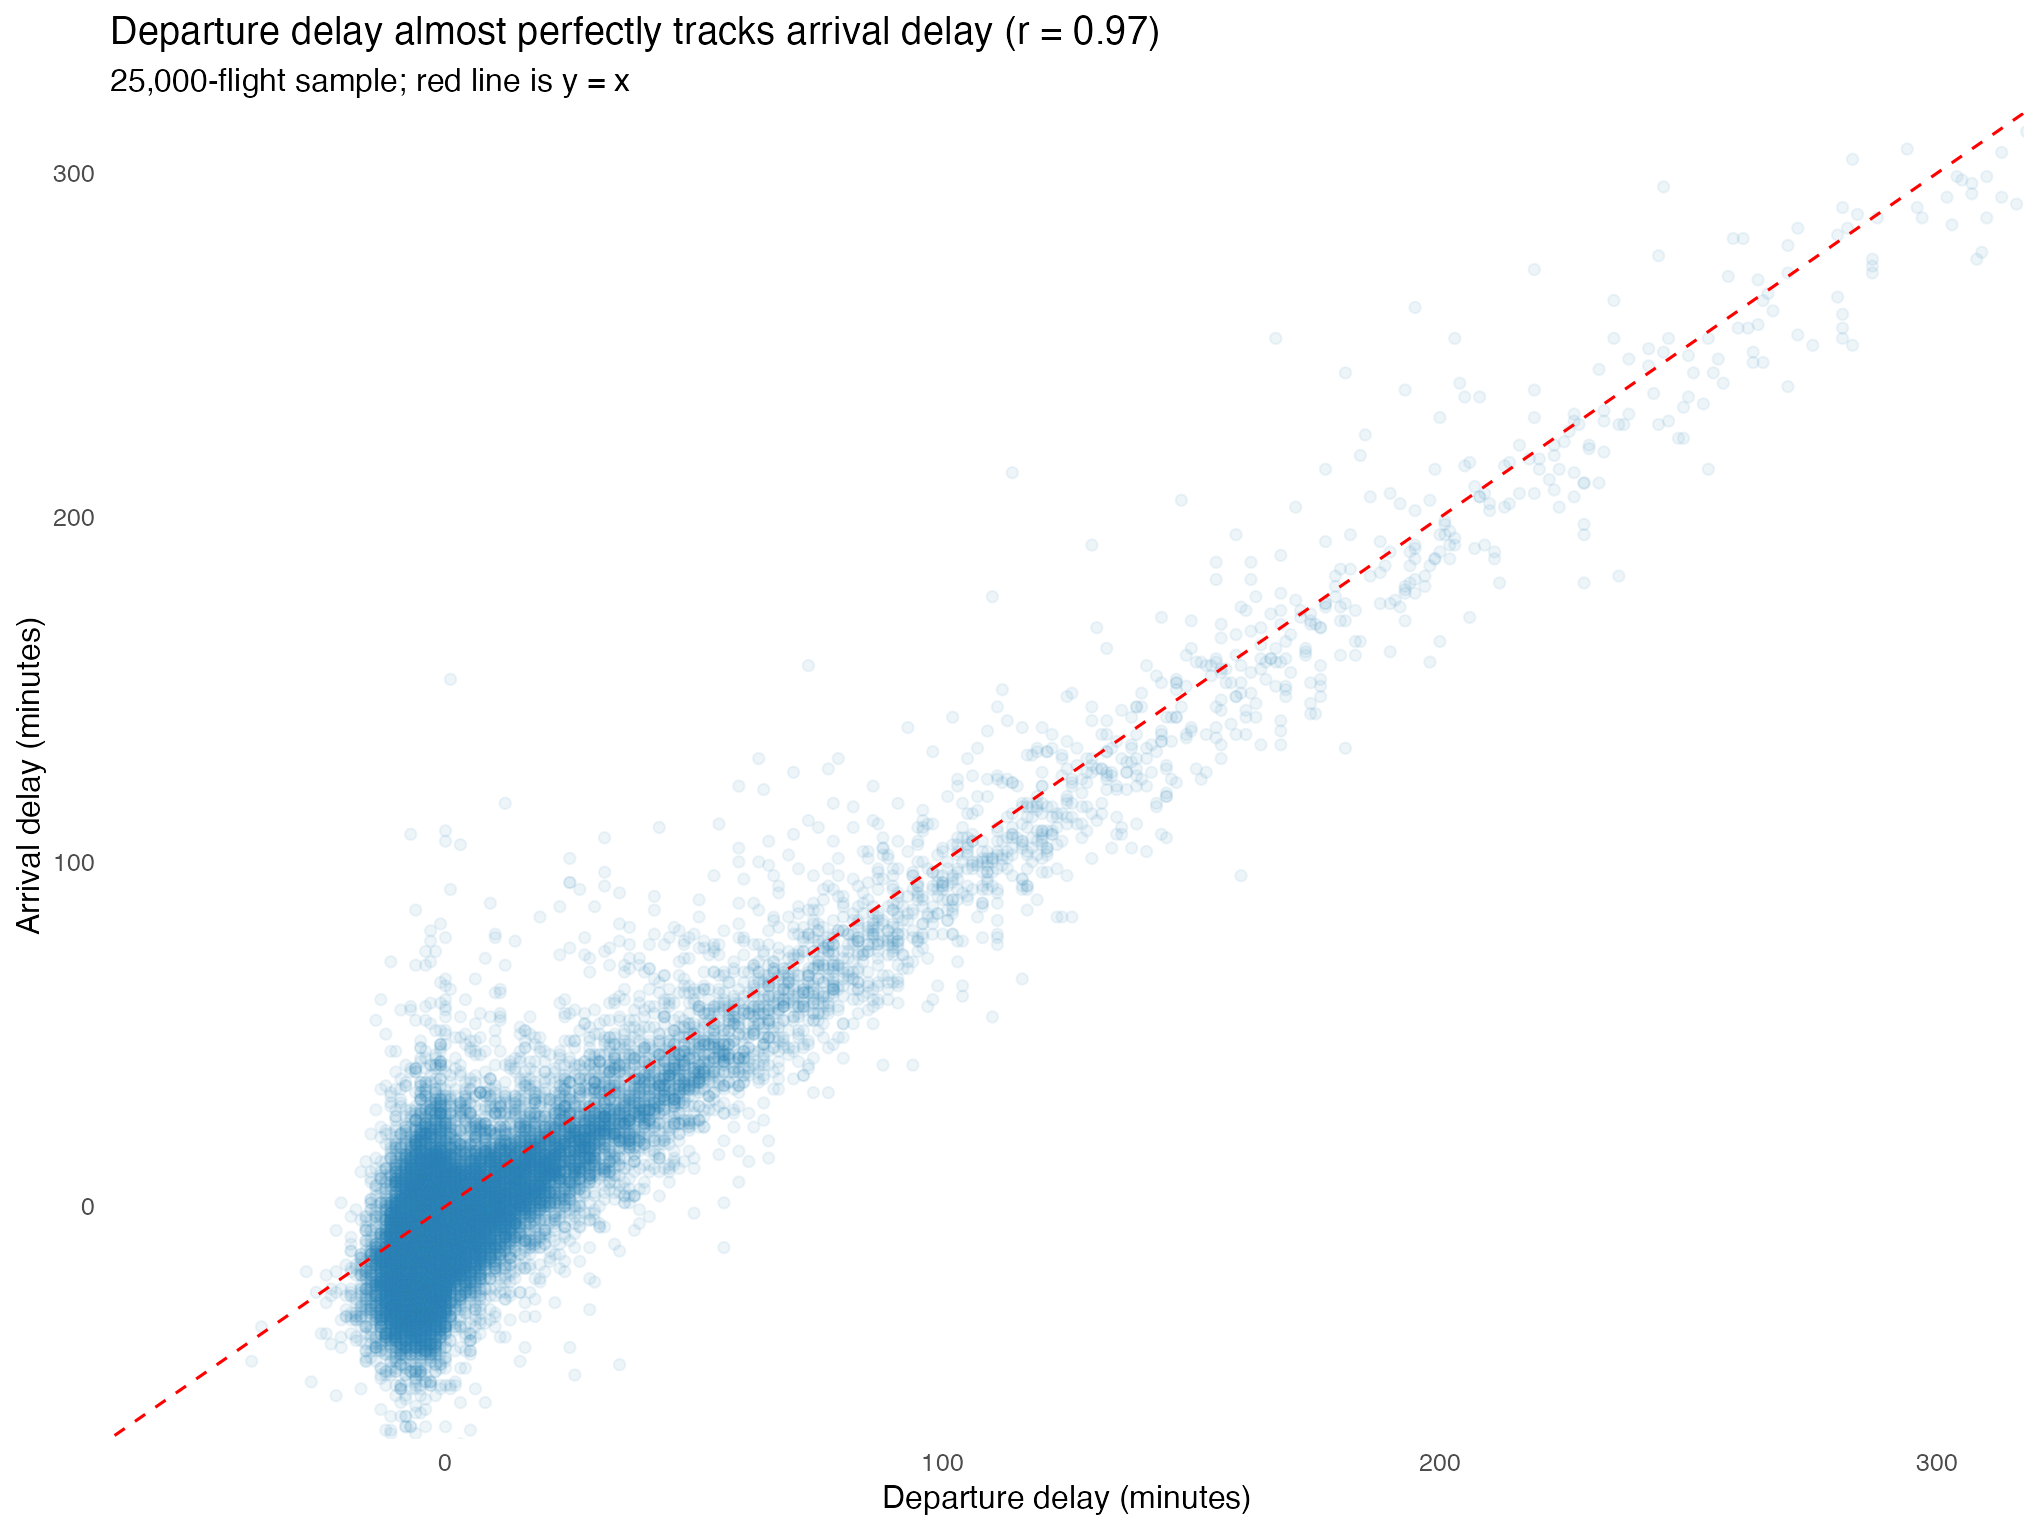

In [51]:
# Scatter on a 25k sample with a reference line
set.seed(2024)
df_clean |>
  slice_sample(n = 25000) |>
  ggplot(aes(dep_delay, arr_delay)) +
  geom_point(alpha = 0.08, colour = report_fill) +
  geom_abline(slope = 1, intercept = 0, colour = "red", linetype = "dashed") +
  coord_cartesian(xlim = c(-50, 300), ylim = c(-50, 300)) +
  labs(title = "Departure delay almost perfectly tracks arrival delay (r = 0.97)",
       subtitle = "25,000-flight sample; red line is y = x",
       x = "Departure delay (minutes)", y = "Arrival delay (minutes)")

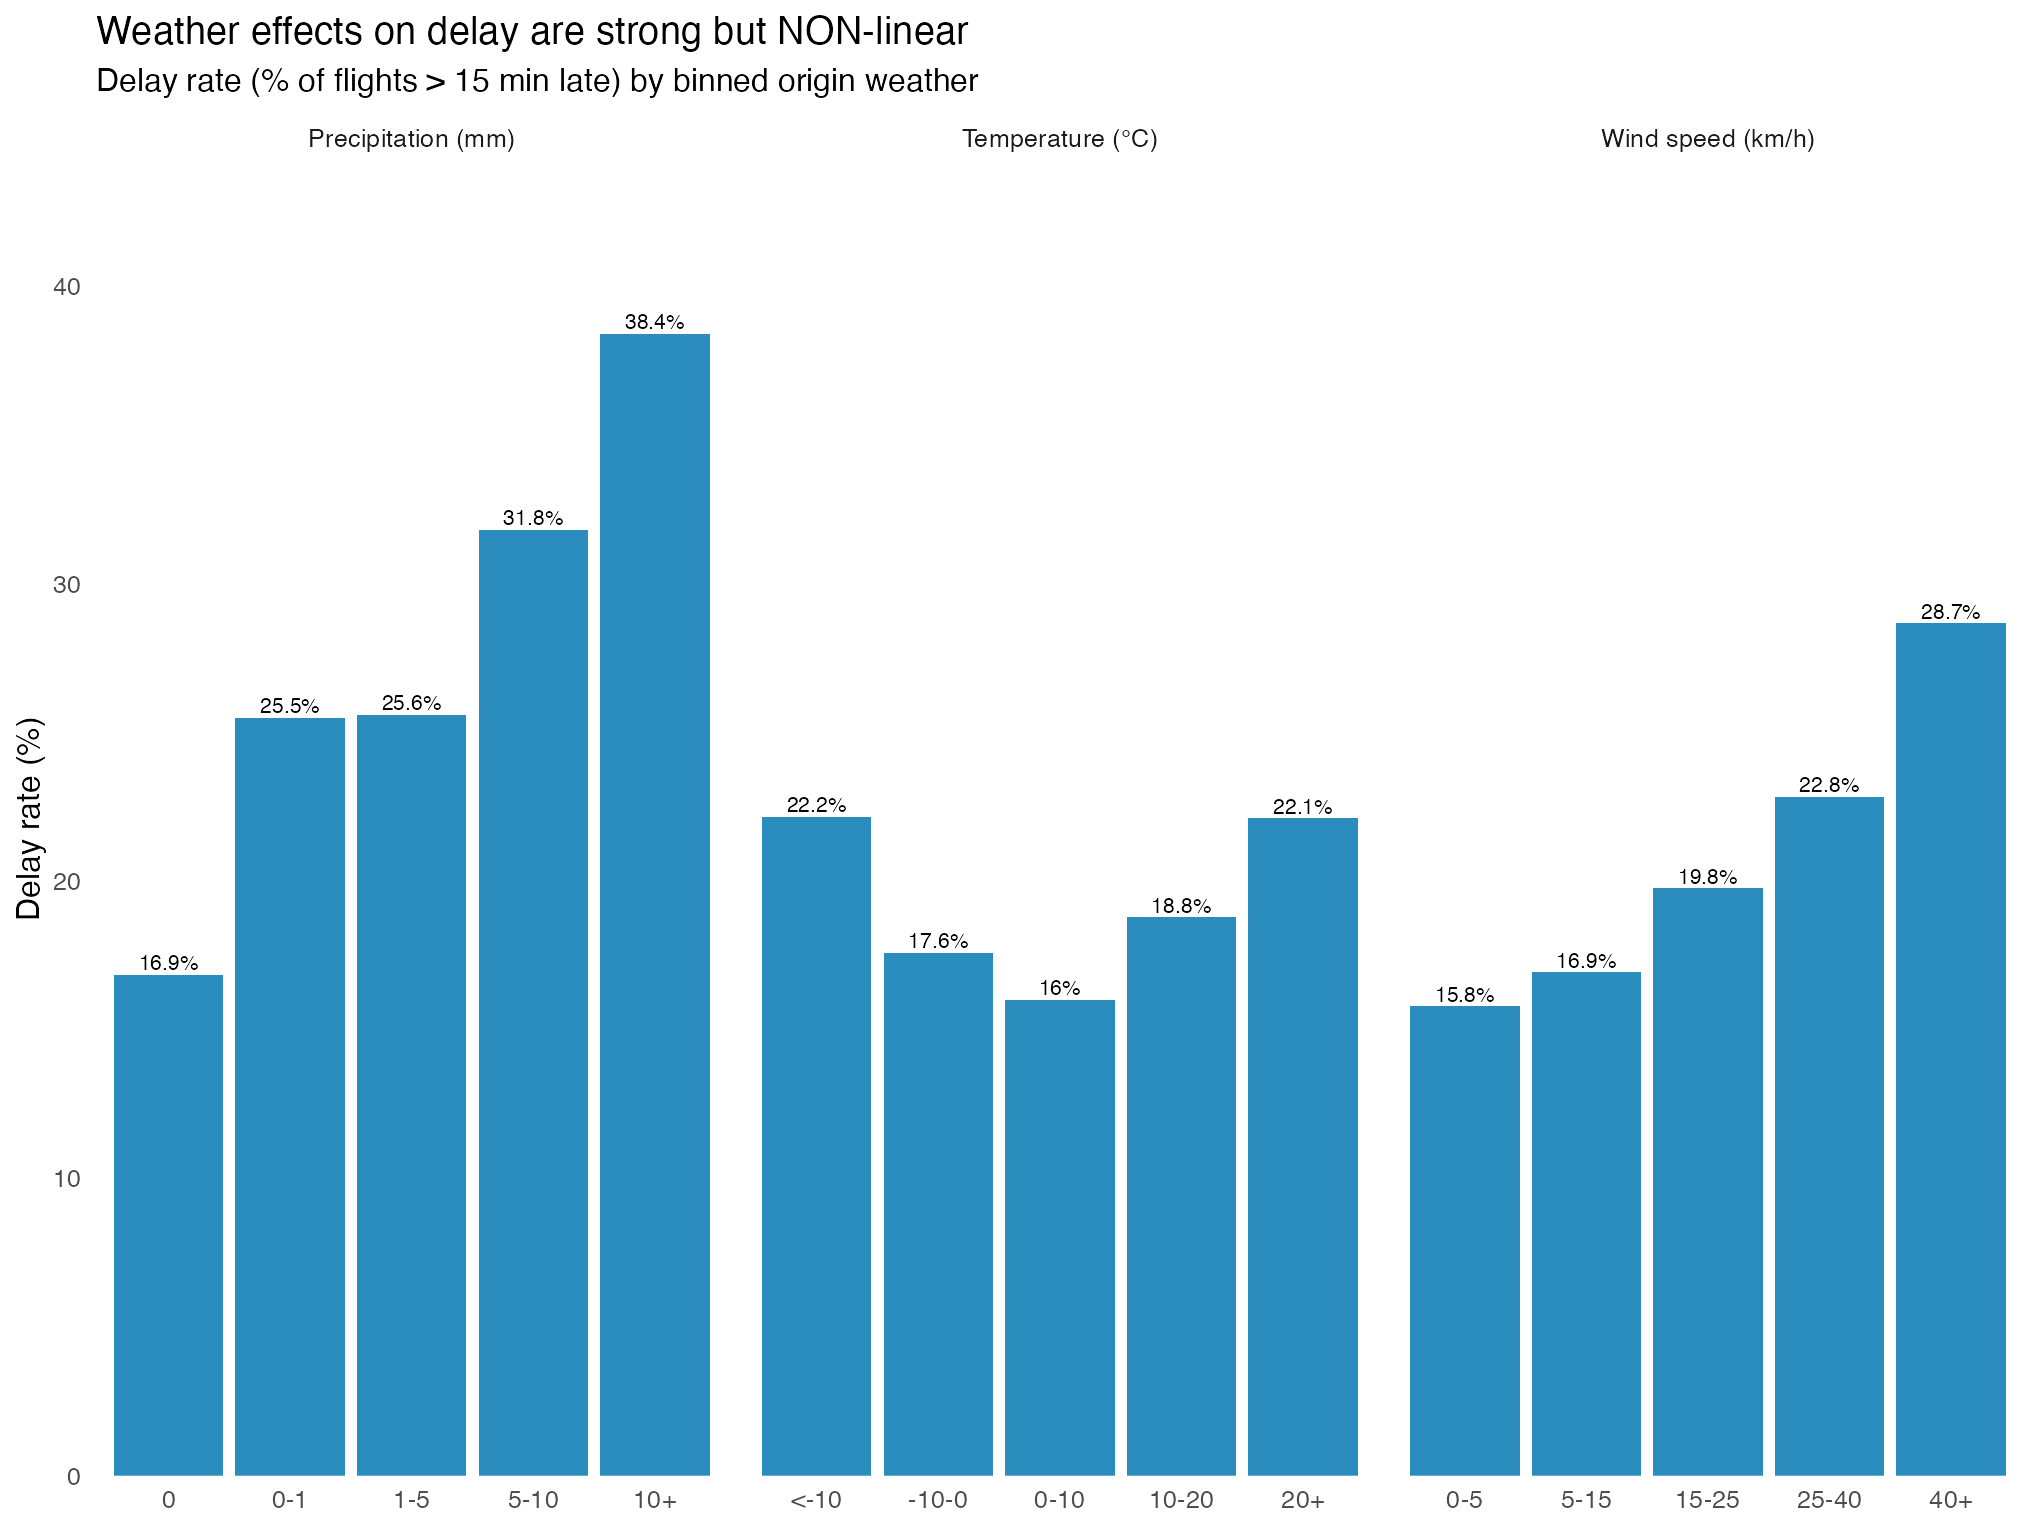

In [52]:
# Delay rate (% > 15 min) across binned weather conditions at the origin.
make_bin_summary <- function(data, var, breaks, labels, varname) {
  data |>
    filter(!is.na(.data[[var]])) |>
    mutate(bin = cut(.data[[var]], breaks = breaks, labels = labels)) |>
    group_by(bin) |>
    summarise(delay_rate = 100 * mean(arr_delay > 15), .groups = "drop") |>
    mutate(driver = varname)
}

prcp_b <- make_bin_summary(df_clean, "o_prcp",
            c(-Inf, 0, 1, 5, 10, Inf),
            c("0", "0-1", "1-5", "5-10", "10+"), "Precipitation (mm)")
wspd_b <- make_bin_summary(df_clean, "o_wspd",
            c(-Inf, 5, 15, 25, 40, Inf),
            c("0-5", "5-15", "15-25", "25-40", "40+"), "Wind speed (km/h)")
temp_b <- make_bin_summary(df_clean, "o_temp",
            c(-Inf, -10, 0, 10, 20, Inf),
            c("<-10", "-10-0", "0-10", "10-20", "20+"), "Temperature (\u00b0C)")

bind_rows(prcp_b, wspd_b, temp_b) |>
  ggplot(aes(bin, delay_rate, group = driver)) +
  geom_col(fill = "#2b8cbe") +
  geom_text(aes(label = paste0(round(delay_rate, 1), "%")), vjust = -0.3, size = 2.8) +
  facet_wrap(~ driver, scales = "free_x") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  labs(title = "Weather effects on delay are strong but NON-linear",
       subtitle = "Delay rate (% of flights > 15 min late) by binned origin weather",
       x = NULL, y = "Delay rate (%)")

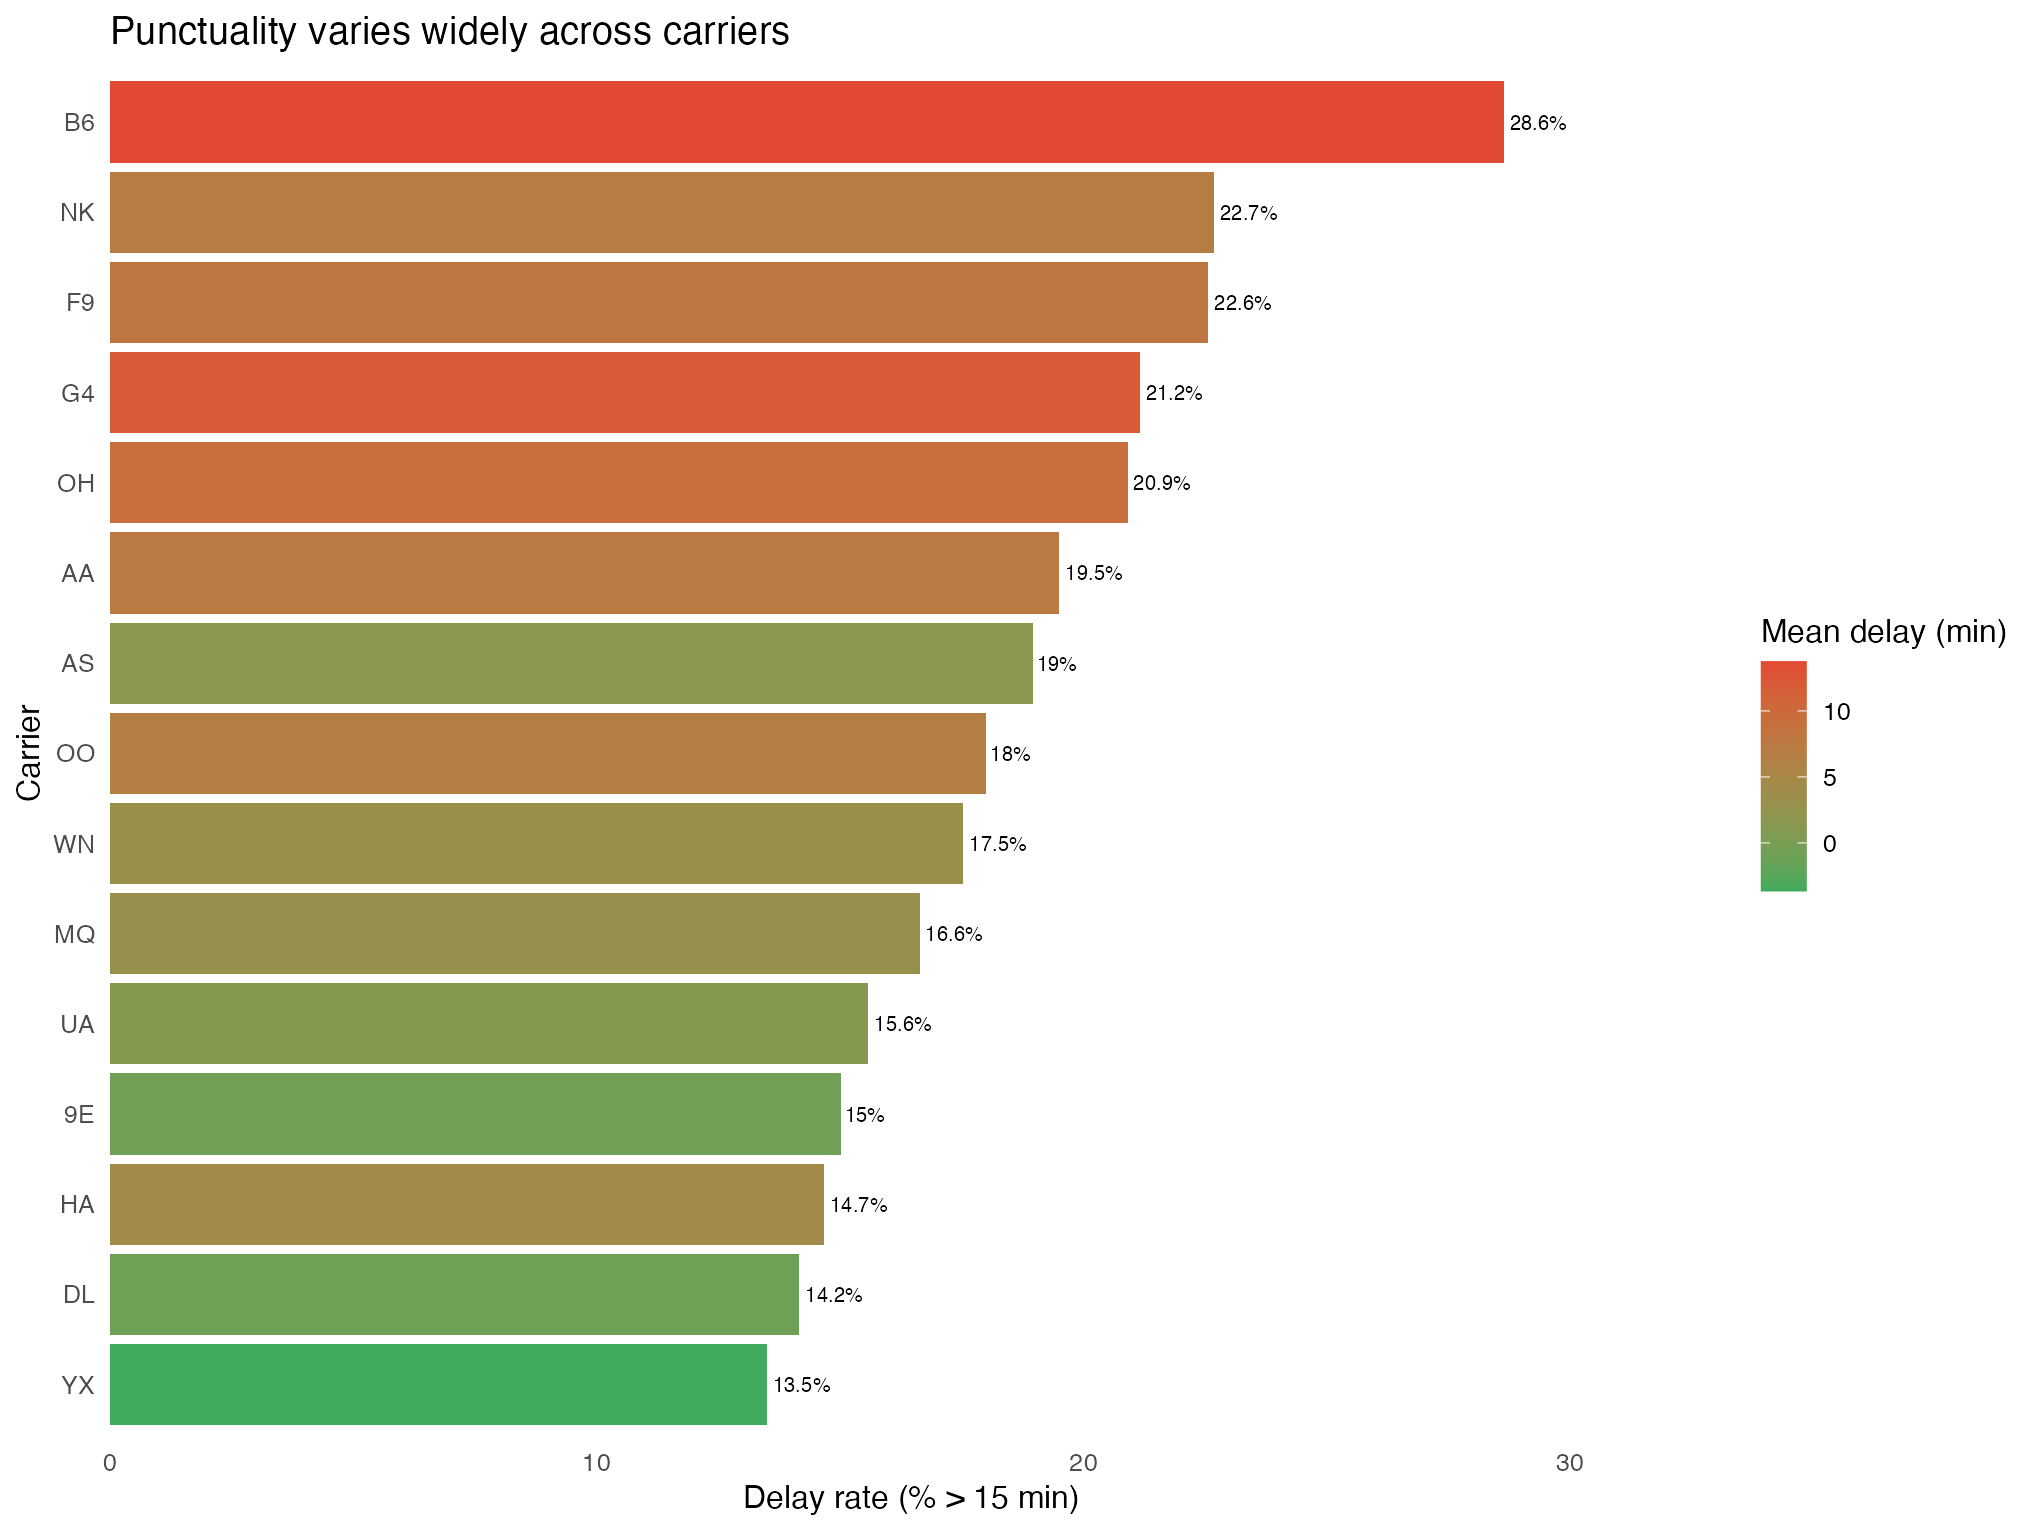

In [53]:
df_clean |>
  group_by(op_carrier) |>
  summarise(delay_rate = 100 * mean(arr_delay > 15),
            mean_delay  = mean(arr_delay), n = n(), .groups = "drop") |>
  ggplot(aes(reorder(op_carrier, delay_rate), delay_rate, fill = mean_delay)) +
  geom_col() +
  geom_text(aes(label = paste0(round(delay_rate, 1), "%")), hjust = -0.1, size = 2.7) +
  coord_flip(clip = "off") +
  scale_fill_gradient(low = "#41ab5d", high = "#e34a33",
                      name = "Mean delay (min)") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  labs(title = "Punctuality varies widely across carriers",
       x = "Carrier", y = "Delay rate (% > 15 min)")

year,n_flights,mean_arr_delay,median_arr,delay_rate_pct,mean_dep_delay
2023,"558,609",0.43,-8,15.05,8.16
2024,"574,434",6.95,-6,20.38,13.34


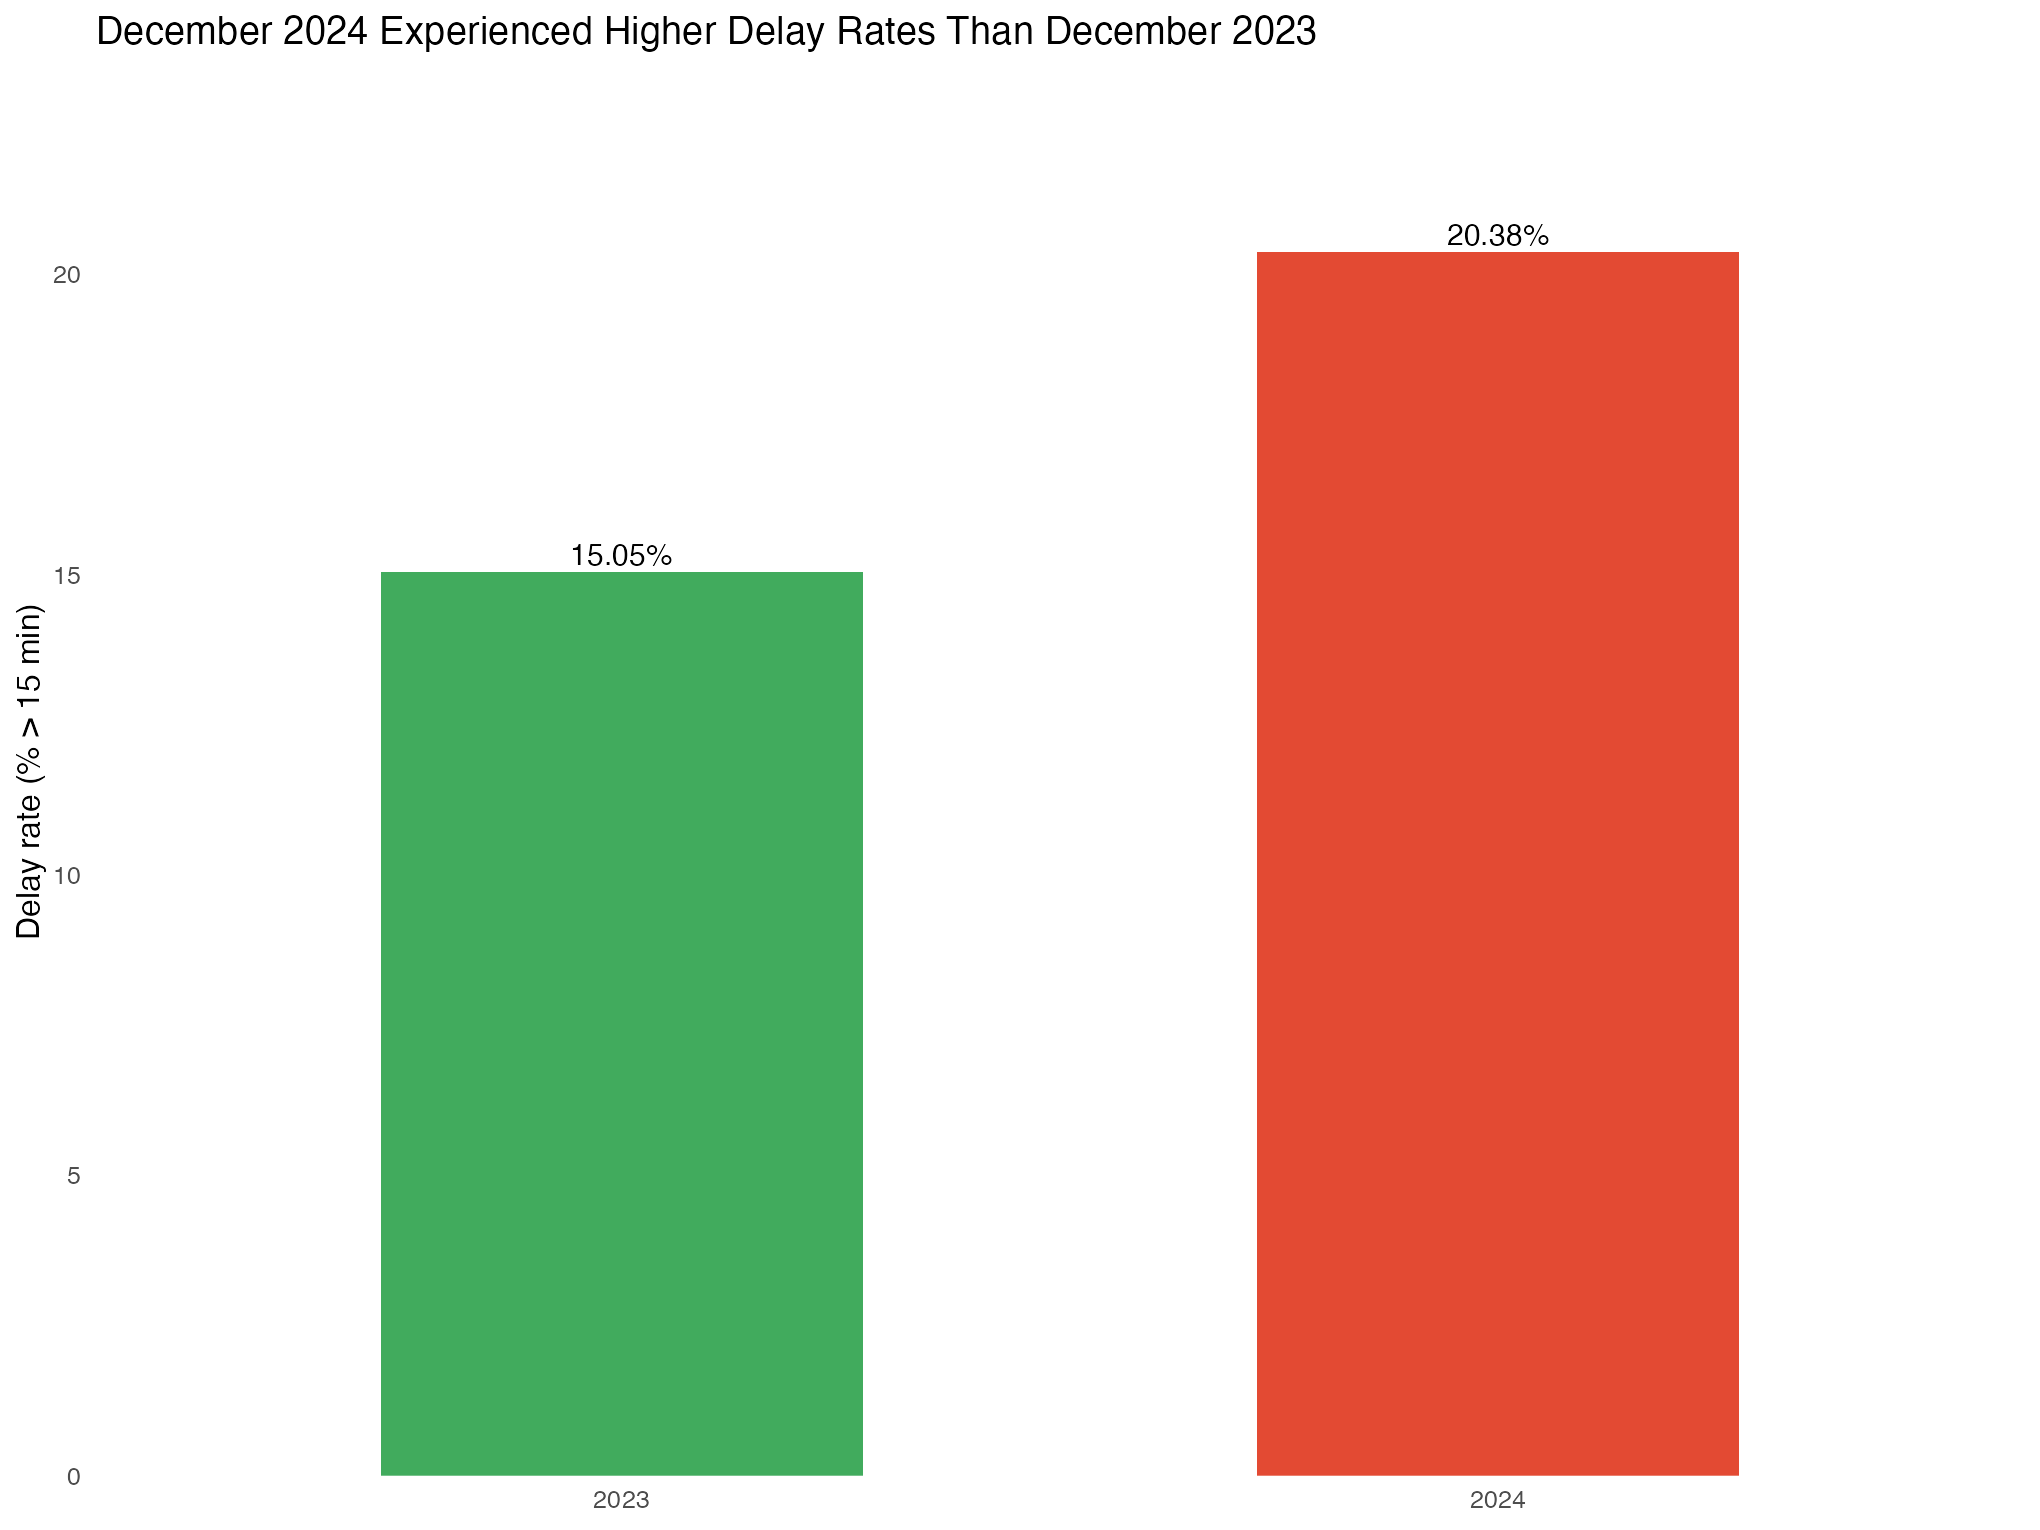

In [54]:
year_summary <- df_clean |>
  group_by(year) |>
  summarise(n_flights      = n(),
            mean_arr_delay = round(mean(arr_delay), 2),
            median_arr     = median(arr_delay),
            delay_rate_pct = round(100 * mean(arr_delay > 15), 2),
            mean_dep_delay = round(mean(dep_delay), 2),
            .groups = "drop")

year_summary |>
  kable(caption = "Year-over-year delay comparison",
        format.args = list(big.mark = ",")) |>
  kable_styling(full_width = FALSE, bootstrap_options = c("striped", "hover"))

ggplot(year_summary, aes(year, delay_rate_pct, fill = year)) +
  geom_col(width = 0.55) +
  geom_text(aes(label = paste0(delay_rate_pct, "%")), vjust = -0.3, size = 4) +
  scale_fill_manual(values = c("2023" = "#41ab5d", "2024" = "#e34a33")) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +
  labs(title = "December 2024 Experienced Higher Delay Rates Than December 2023",
       x = NULL, y = "Delay rate (% > 15 min)") +
  theme(legend.position = "none")

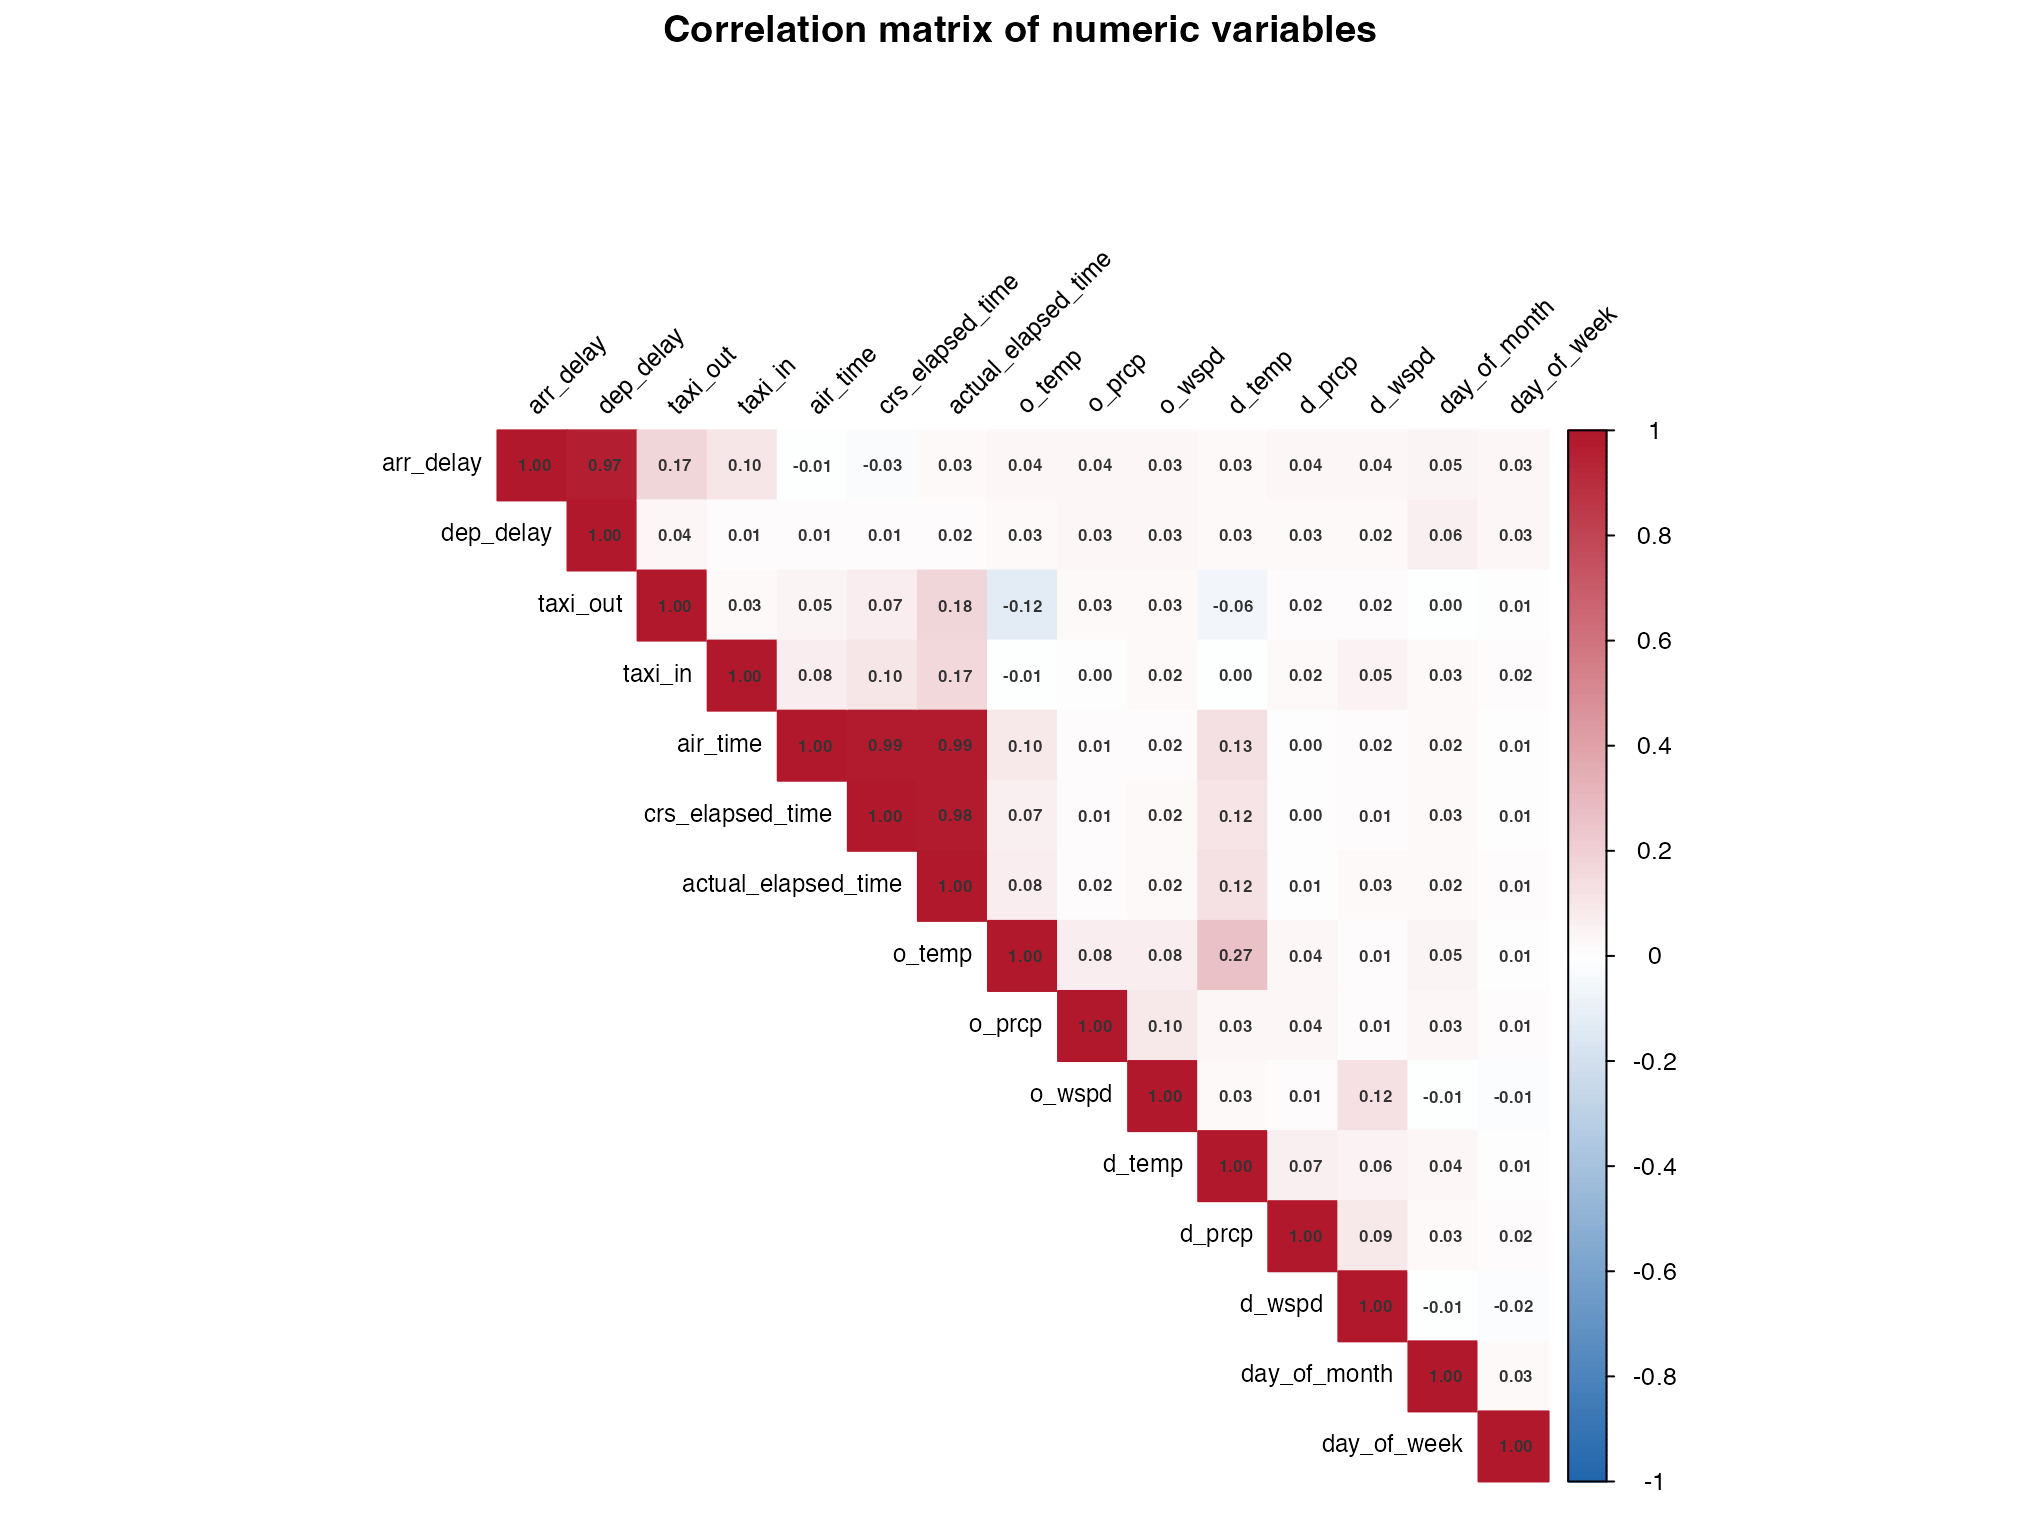

In [55]:
corr_vars <- c("arr_delay", "dep_delay", "taxi_out", "taxi_in", "air_time",
               "crs_elapsed_time", "actual_elapsed_time",
               "o_temp", "o_prcp", "o_wspd", "d_temp", "d_prcp", "d_wspd",
               "day_of_month", "day_of_week")

cmat <- cor(select(df_clean, all_of(corr_vars)), use = "pairwise.complete.obs")

corrplot(cmat, method = "color", type = "upper",
         tl.col = "black", tl.cex = 0.75, tl.srt = 45,
         addCoef.col = "grey20", number.cex = 0.55,
         col = colorRampPalette(c("#2166ac", "white", "#b2182b"))(200),
         mar = c(0, 0, 1.5, 0),
         title = "Correlation matrix of numeric variables")

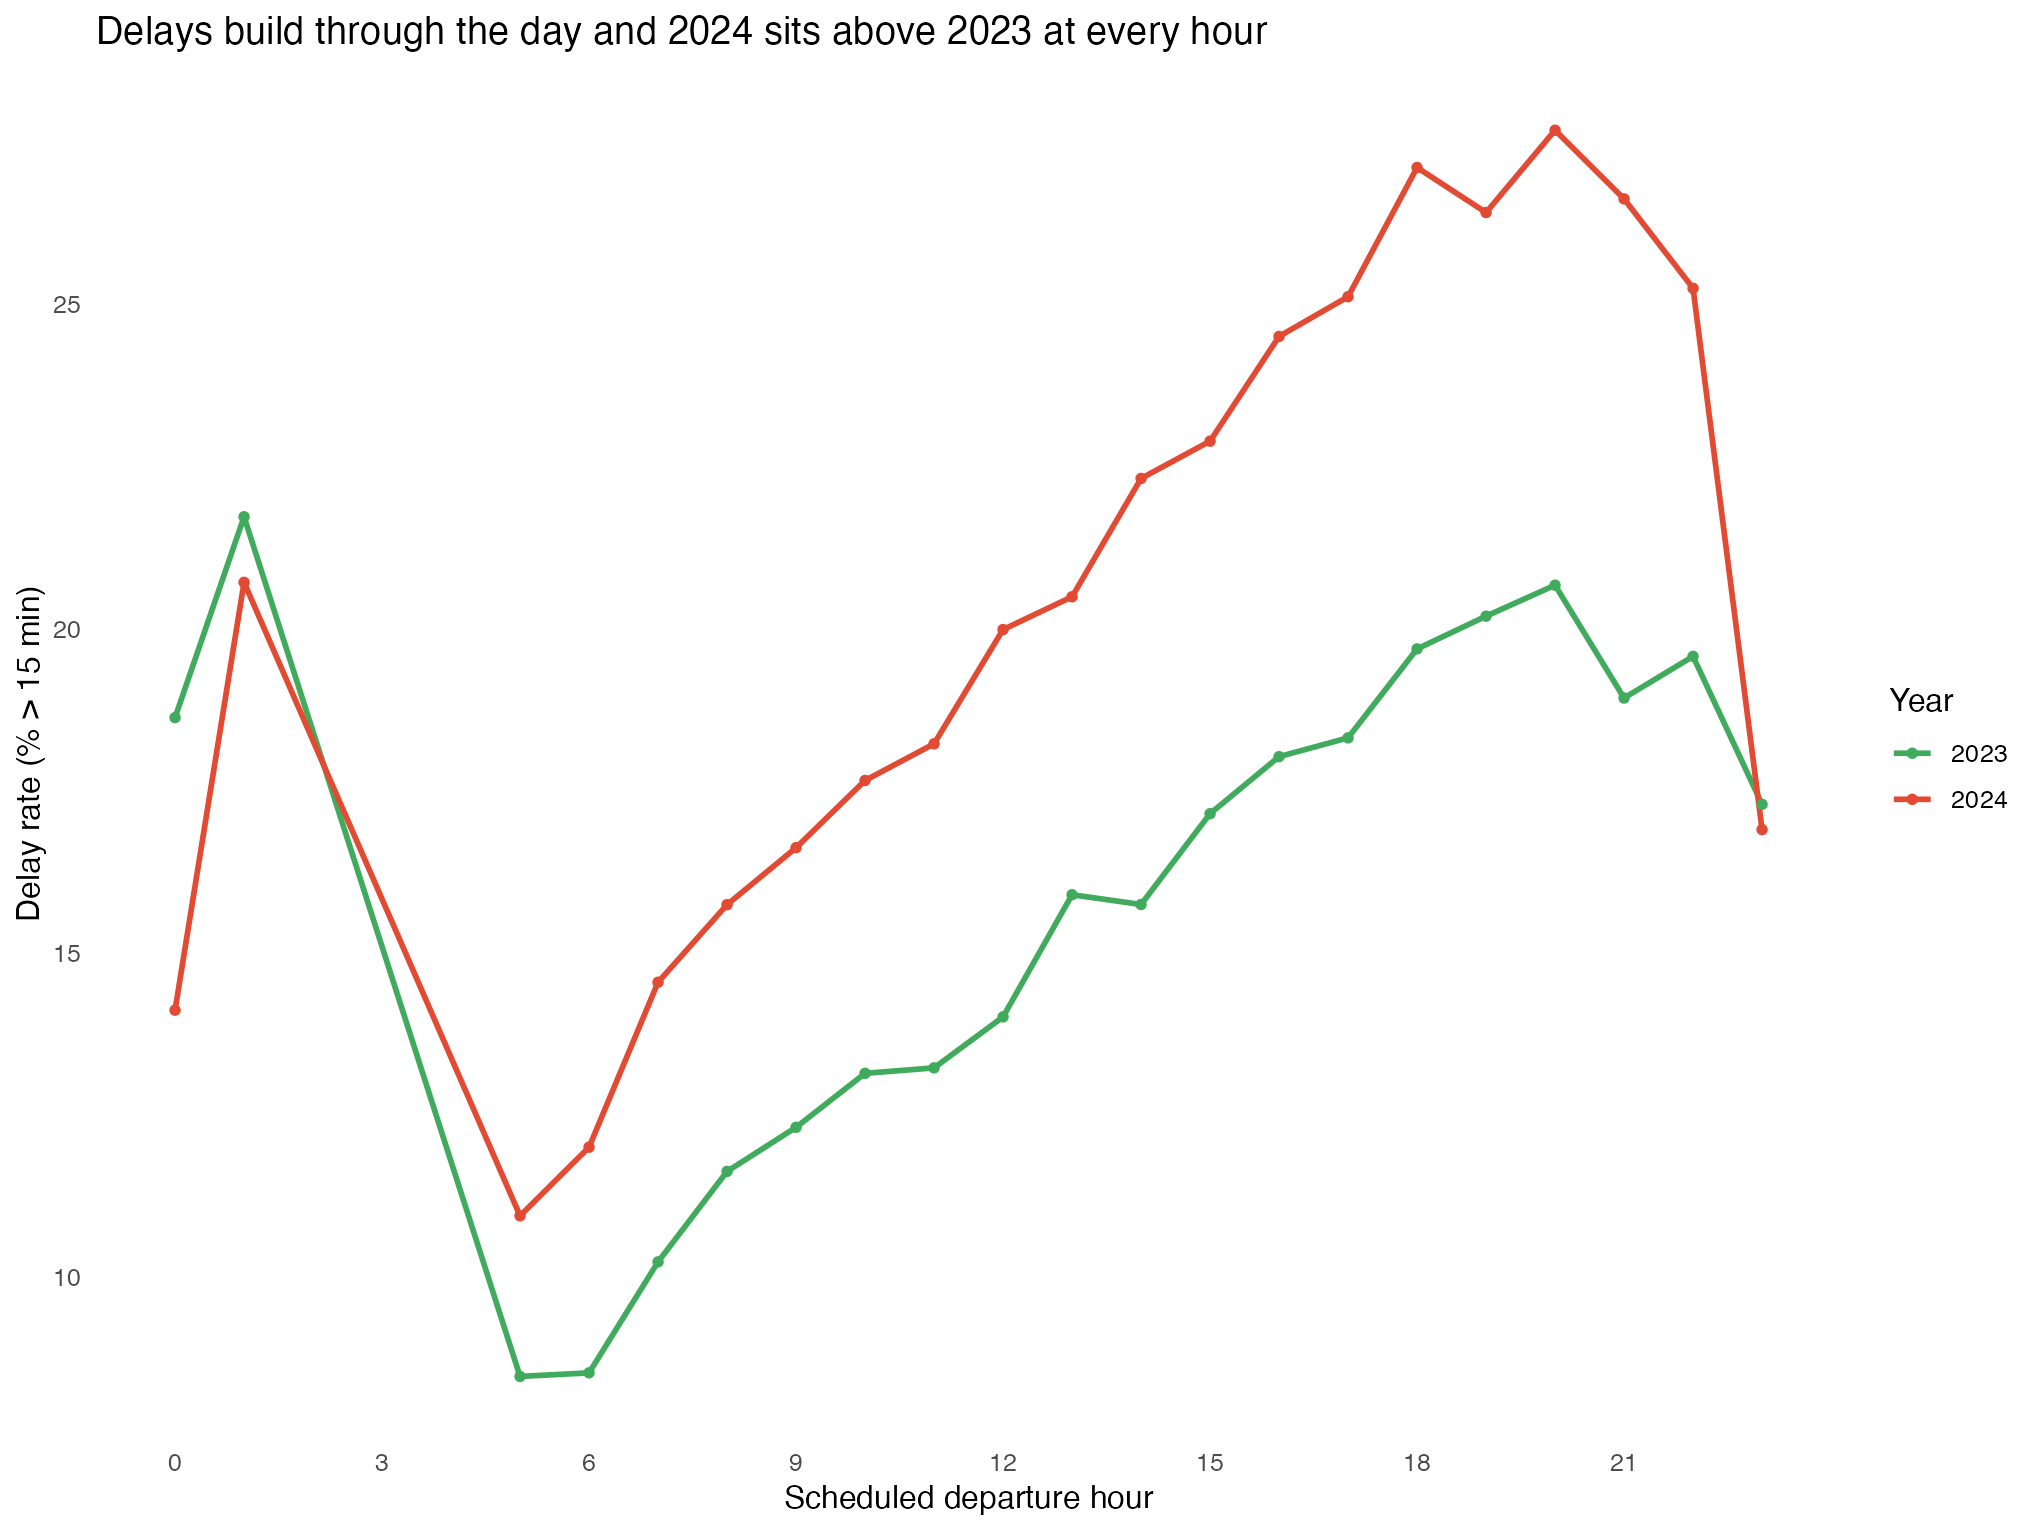

In [56]:
df_clean |>
  group_by(year, dep_hour) |>
  summarise(delay_rate = 100 * mean(arr_delay > 15), n = n(), .groups = "drop") |>
  filter(n >= 200) |>
  ggplot(aes(dep_hour, delay_rate, colour = year)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.3) +
  scale_colour_manual(values = c("2023" = "#41ab5d", "2024" = "#e34a33")) +
  scale_x_continuous(breaks = seq(0, 23, 3)) +
  labs(title = "Delays build through the day and 2024 sits above 2023 at every hour",
       x = "Scheduled departure hour", y = "Delay rate (% > 15 min)",
       colour = "Year")

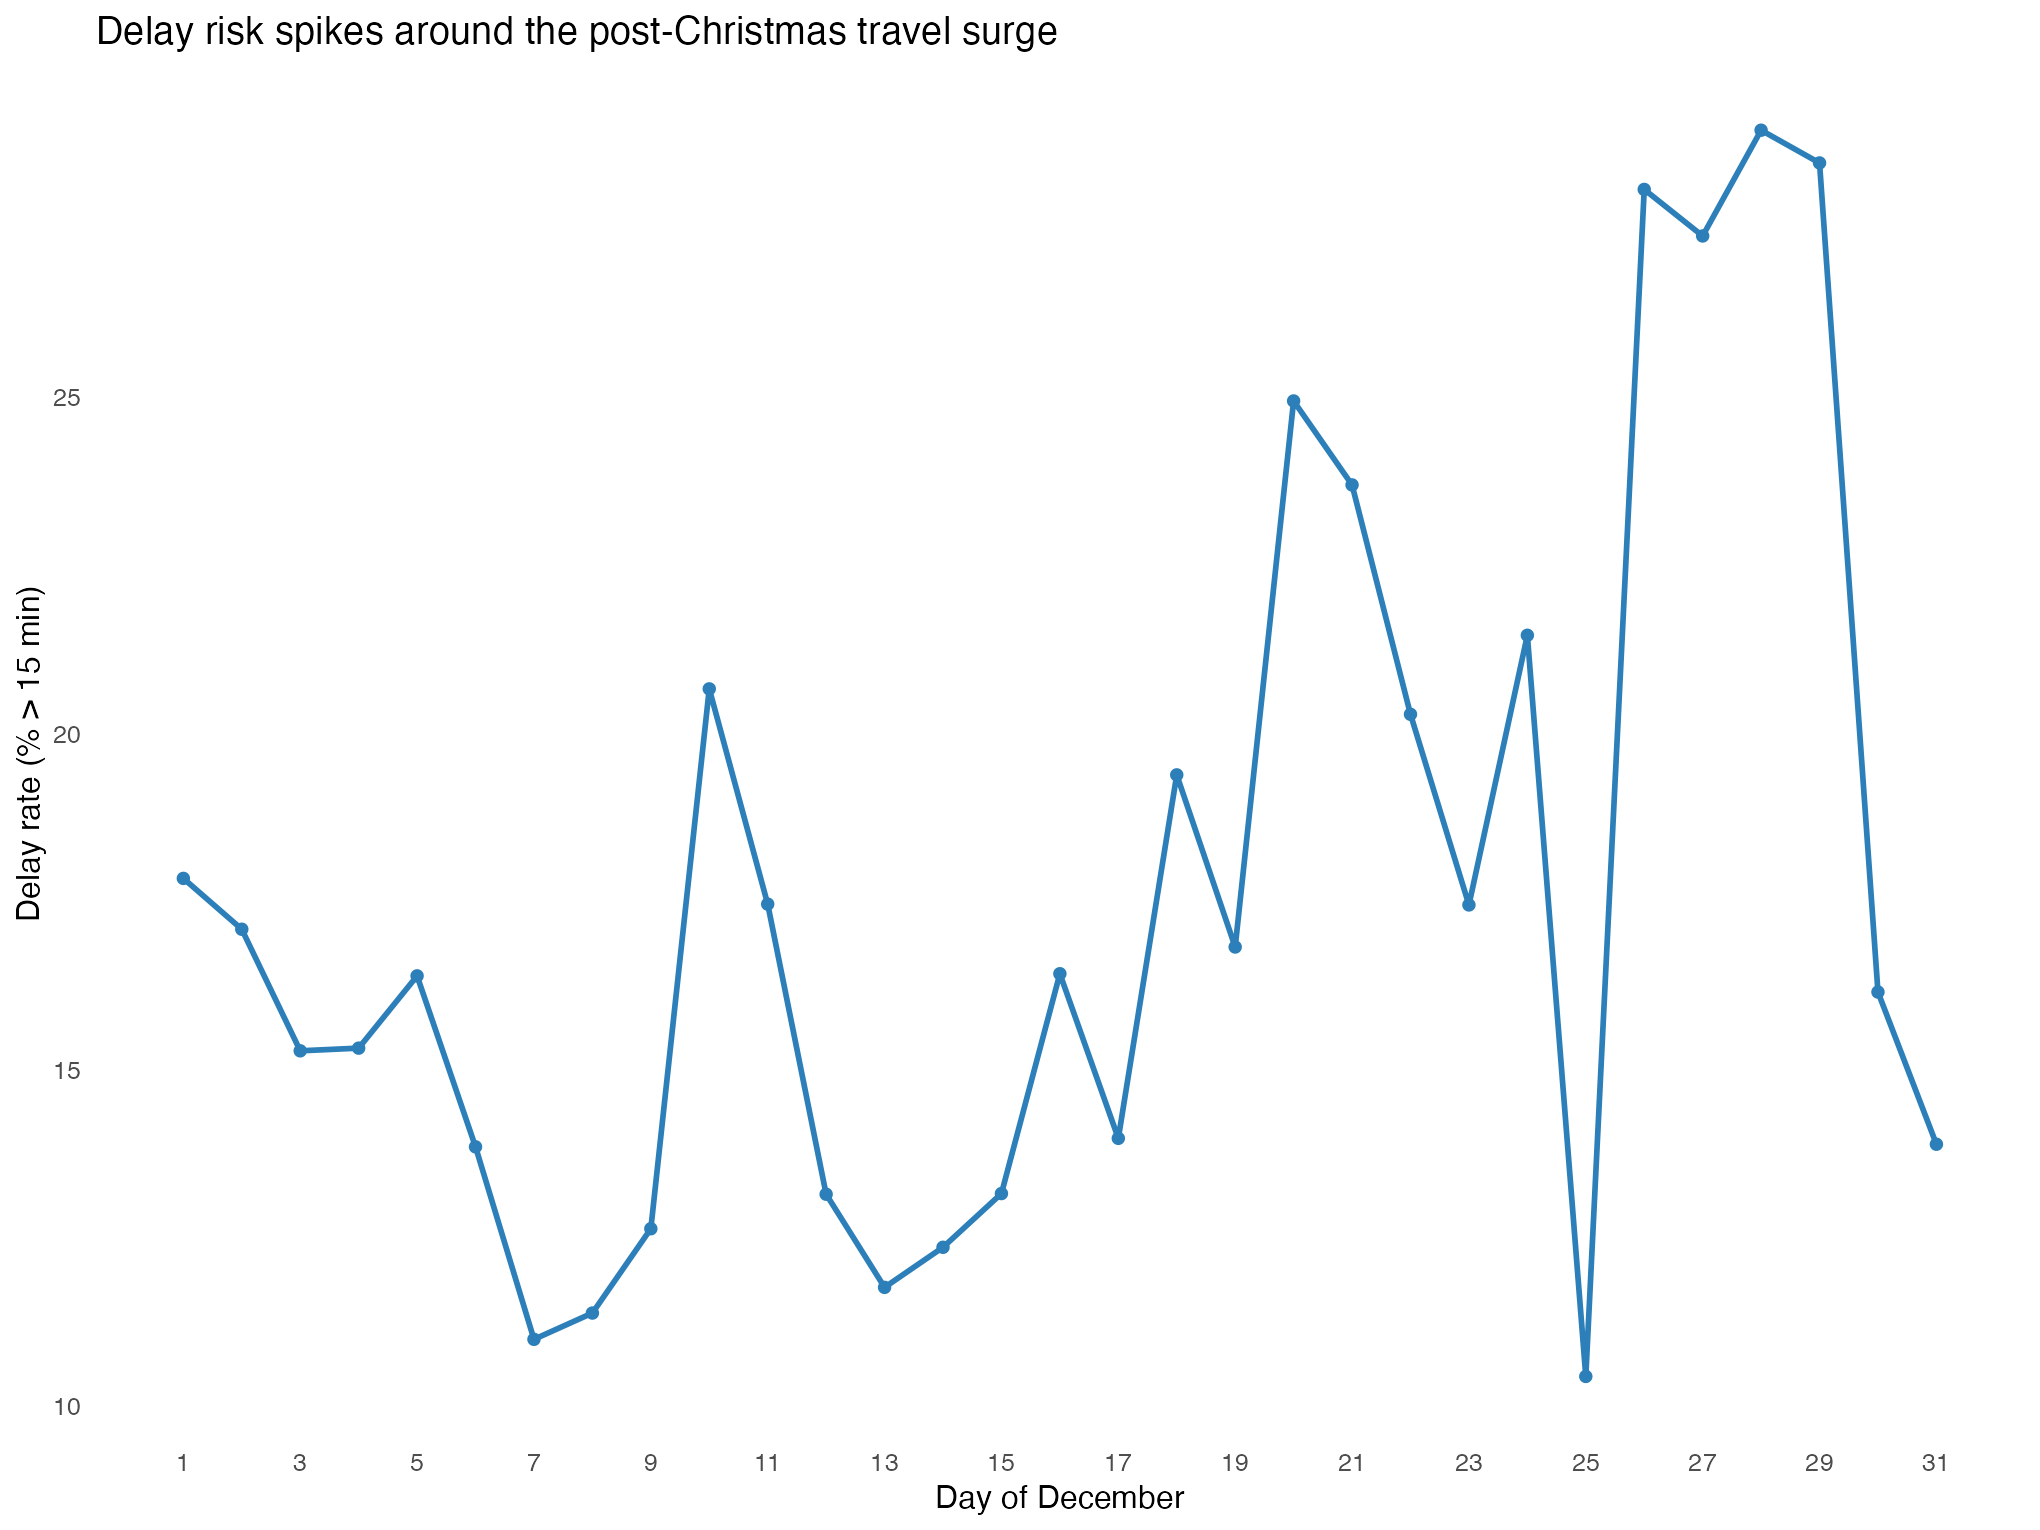

In [57]:
df_clean |>
  group_by(day_of_month) |>
  summarise(delay_rate = 100 * mean(arr_delay > 15), .groups = "drop") |>
  ggplot(aes(day_of_month, delay_rate)) +
  geom_line(colour = report_fill, linewidth = 1) +
  geom_point(colour = report_fill) +
  scale_x_continuous(breaks = seq(1, 31, 2)) +
  labs(title = "Delay risk spikes around the post-Christmas travel surge",
       x = "Day of December", y = "Delay rate (% > 15 min)")

In [58]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: aarch64-apple-darwin20
Running under: macOS Sequoia 15.7.4

Matrix products: default
BLAS:   /System/Library/Frameworks/Accelerate.framework/Versions/A/Frameworks/vecLib.framework/Versions/A/libBLAS.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.1

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: Asia/Kuala_Lumpur
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] kableExtra_1.4.0   knitr_1.51         patchwork_1.3.2    corrplot_0.95     
 [5] rlang_1.2.0        pROC_1.19.0.1      ranger_0.18.0      glmnet_5.0        
 [9] Matrix_1.7-4       skimr_2.2.2        janitor_2.2.1      yardstick_1.4.0   
[13] workflowsets_1.1.1 workflows_1.3.0    tune_2.1.0         tailor_0.1.0      
[17] rsample_1.3.2      recipes_1.3.2      parsnip_1.5.0      m